In [614]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.image as img
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, log_loss


%matplotlib inline

In [615]:
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/test.csv")
test_outcome = pd.read_csv("data/gender_submission.csv")



test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [616]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [617]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [618]:
plt.style.use('seaborn-v0_8-whitegrid')
matplotlib.rcParams.update({"font.size": 14})

train_data.Pclass = [str(i) for i in train_data.Pclass]

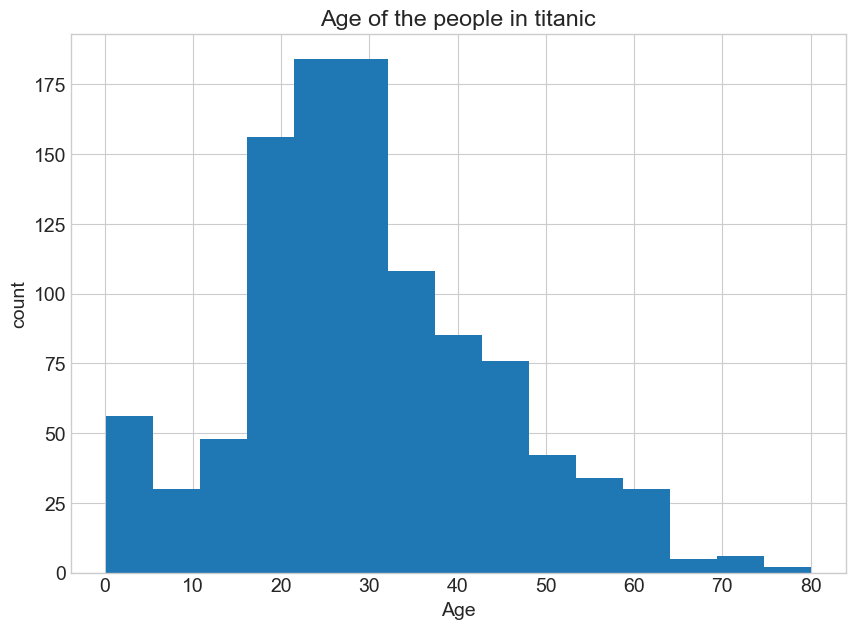

In [619]:
plt.figure(figsize=(10,7))


plt.hist(pd.concat([train_data.Age, test_data.Age]), bins=15)

plt.title("Age of the people in titanic")
plt.xlabel("Age")
plt.ylabel("count")

plt.show()

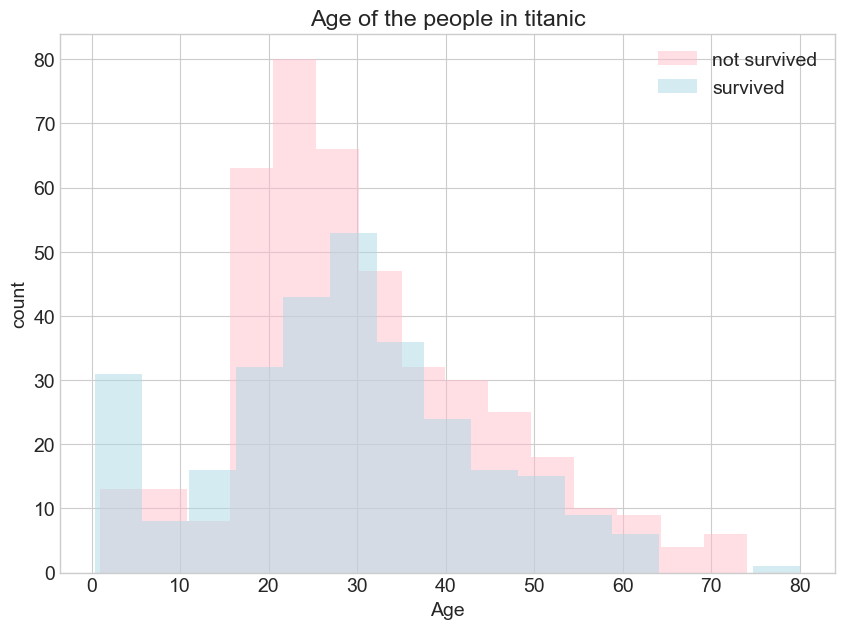

In [620]:
plt.figure(figsize=(10,7))

plt.hist(train_data.loc[train_data.Survived == 0]["Age"], alpha=0.5, bins=15, color="pink", label="not survived")
plt.hist(train_data.loc[train_data.Survived == 1]["Age"], alpha=0.5, bins=15, color="lightblue",label="survived")

plt.title("Age of the people in titanic")
plt.xlabel("Age")
plt.ylabel("count")

plt.legend()
plt.show()

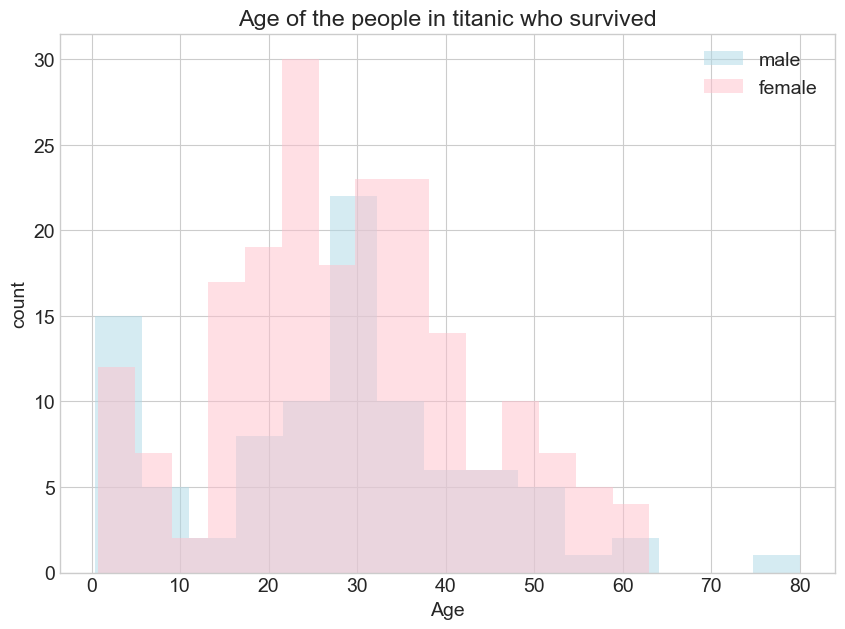

In [621]:
plt.figure(figsize=(10,7))

plt.hist(train_data.loc[(train_data.Survived == 1) & (train_data.Sex == "male")]["Age"], alpha=0.5, bins=15, color="lightblue", label="male")
plt.hist(train_data.loc[(train_data.Survived == 1) & (train_data.Sex == "female")]["Age"], alpha=0.5, bins=15, color="pink",label="female")


plt.title("Age of the people in titanic who survived")
plt.xlabel("Age")
plt.ylabel("count")

plt.legend()
plt.show()

In [622]:
# predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
# outcome = 'Survived'

# train_data = train_data.dropna()

# X = pd.get_dummies(train_data[predictors], drop_first=True)
# y = train_data[outcome]

# model_simple = LogisticRegression()
# model_simple.fit(X,y,)

def print_metrics(y_true,y_pred,title):
    print(f"Metrics for {title}")
    print("-----------------------------")
    print(f"Accuracy: {accuracy_score(y_true,y_pred)}")
    print(f"Precision: {precision_score(y_true,y_pred)}")
    print(f"Recall: {recall_score(y_true,y_pred)}")
    print(f"Logloss: {log_loss(y_true,y_pred)}")
    print(f"ROC-AUC: {roc_auc_score(y_true,y_pred)}")
    print("\n")


# test_data.Pclass = [str(i) for i in test_data.Pclass]

# X = pd.get_dummies(test_data[predictors], drop_first=True)
# y = test_outcome.Survived

# deleted_index = set(y.index) - set(X.dropna().index)

# y.drop(deleted_index, inplace=True)
# X.dropna(inplace=True)

In [623]:
# y_pred = model_simple.predict(X)
# print_metrics(y, y_pred,"Simple model")

In [624]:
train_data["Age_int"] = [np.floor(i) for i in train_data.Age]

data = train_data.groupby("Age_int")["Survived"].sum().reset_index()
data

,Age_int,Survived
0,0.0,7
1,1.0,5
2,2.0,3
3,3.0,5
4,4.0,7
...,...,...
66,66.0,0
67,70.0,0
68,71.0,0
69,74.0,0


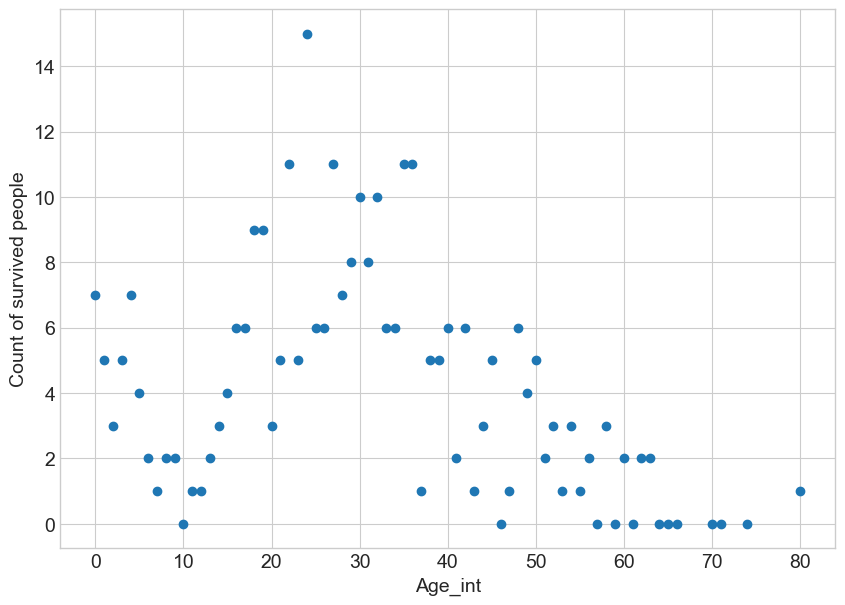

In [625]:
plt.figure(figsize=(10,7))

plt.scatter(x=data.Age_int, y=data.Survived)

plt.xlabel("Age_int")
plt.ylabel("Count of survived people")

plt.show()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


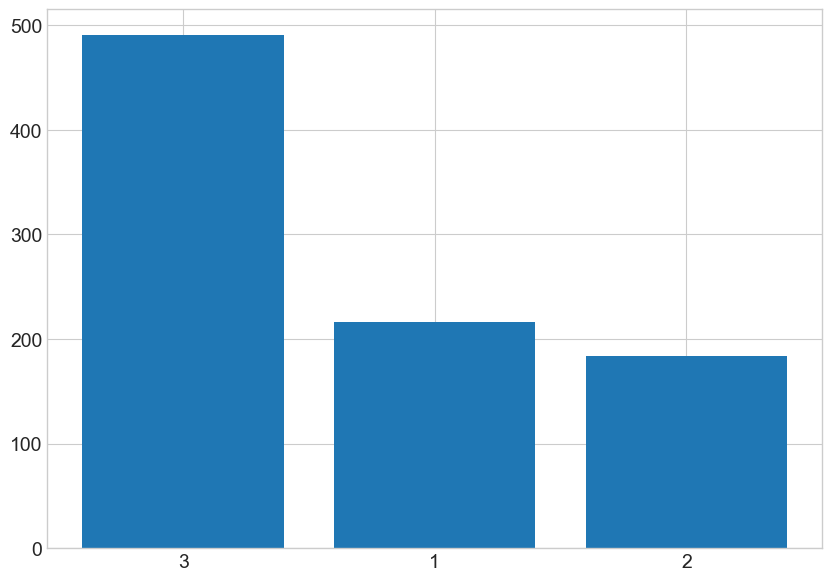

In [626]:
print(train_data.Pclass.value_counts())

plt.figure(figsize=(10,7))

plt.bar(x=train_data.Pclass.value_counts().index, height=train_data.Pclass.value_counts().values)

plt.show()

<Axes: >

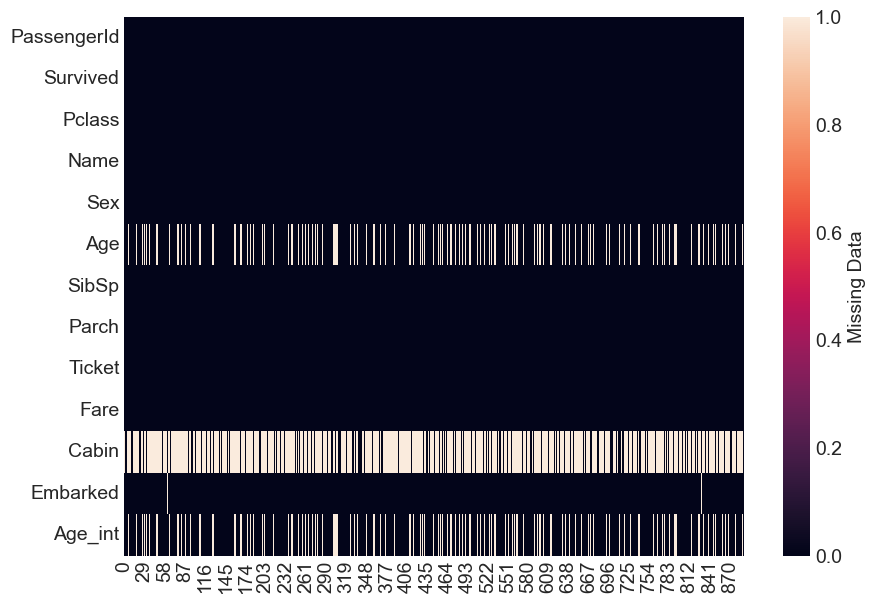

In [627]:
plt.figure(figsize=(10,7))

sns.heatmap(train_data.isna().transpose(), cbar_kws={"label": "Missing Data"})

In [628]:
train_data_num_features = train_data.select_dtypes(include=["float16","float32", "float64"])
train_data_num_features.drop("Age_int", axis=1, inplace=True)
train_data_num_features

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,NaN,23.4500
889,26.0,30.0000


<Figure size 1000x700 with 0 Axes>

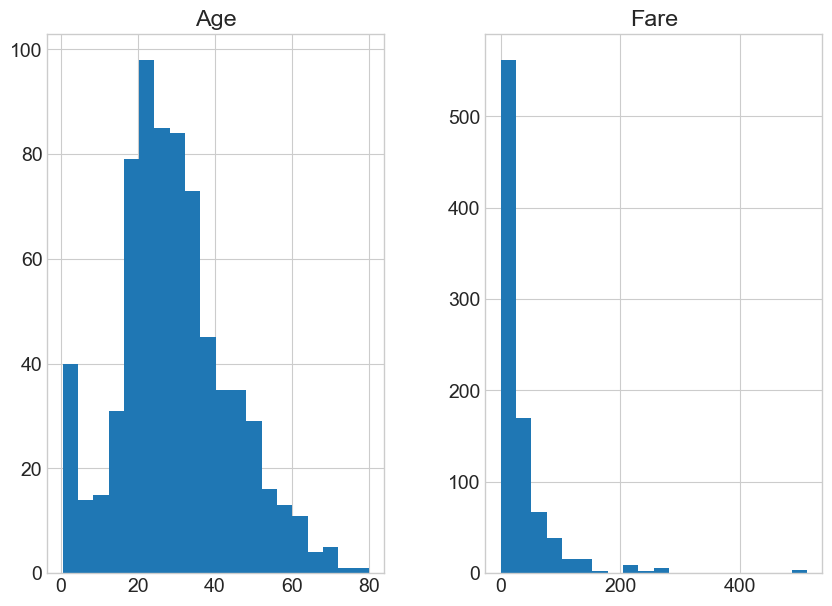

In [629]:
plt.figure(figsize=(10,7))

# sns.displot(train_data_num_features.Age, bins=20)
# sns.displot(train_data_num_features.Fare, bins=20)
train_data_num_features.hist(figsize=(10,7), bins=20, grid=True)

plt.show()

<Axes: >

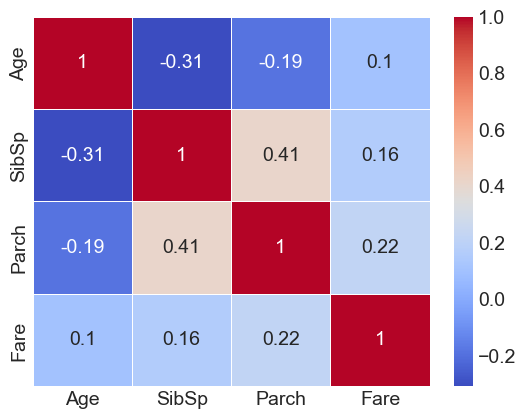

In [630]:

predictors = [ 'Age', 'SibSp', 'Parch', 'Fare']

corr_matrix = train_data[predictors].corr()
corr_matrix = np.round(corr_matrix, 2)
corr_matrix[np.abs(corr_matrix) < 0.1] = 0


sns.heatmap(corr_matrix, annot=True, linewidths=.5, cmap="coolwarm")

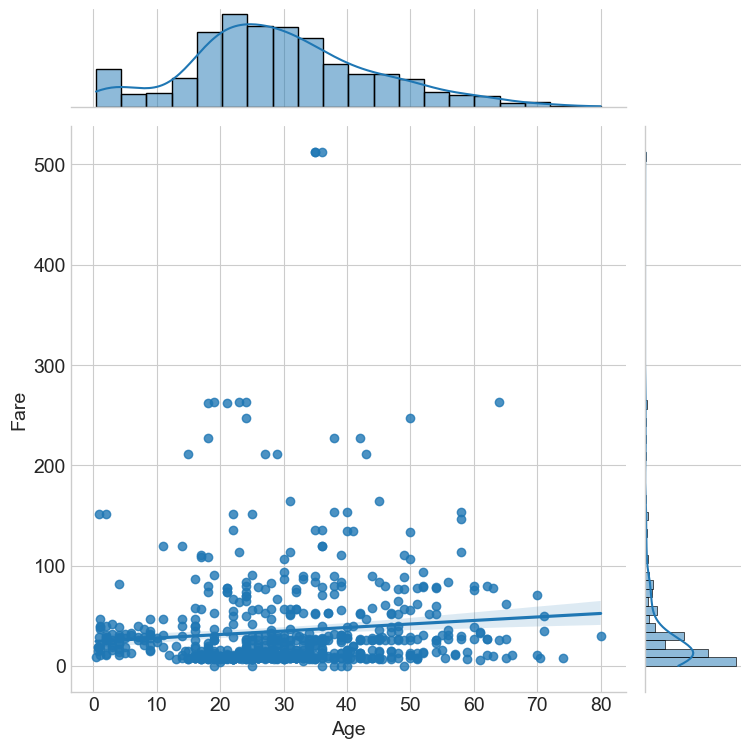

In [631]:
grid = sns.jointplot(x=train_data.Age, y=train_data.Fare, kind="reg")
grid.fig.set_figwidth(8)
grid.fig.set_figheight(8)

plt.show()

In [632]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Age_int      714 non-null    float64
dtypes: float64(3), int64(4), object(6)
memory usage: 90.6+ KB


In [633]:

train_data.describe()

,PassengerId,Survived,Age,SibSp,Parch,Fare,Age_int
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,714.000000
mean,446.000000,0.383838,29.699118,0.523008,0.381594,32.204208,29.679272
std,257.353842,0.486592,14.526497,1.102743,0.806057,49.693429,14.536483
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,20.125000,0.000000,0.000000,7.910400,20.000000
50%,446.000000,0.000000,28.000000,0.000000,0.000000,14.454200,28.000000
75%,668.500000,1.000000,38.000000,1.000000,0.000000,31.000000,38.000000
max,891.000000,1.000000,80.000000,8.000000,6.000000,512.329200,80.000000


In [634]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0


In [635]:
train_data["is_alone"] = 0
train_data.loc[(train_data.SibSp == 0) & (train_data.Parch == 0), "is_alone"] = 1
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [636]:
train_data.is_alone = train_data.is_alone.astype("object")

In [637]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Age_int      714 non-null    float64
 13  is_alone     891 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 97.6+ KB


In [638]:
def func1(x):
  return str(x)

train_data.is_alone.apply(func1)

0      0
1      0
2      1
3      0
4      1
      ..
886    1
887    1
888    0
889    1
890    1
Name: is_alone, Length: 891, dtype: object

In [639]:
import time
from tqdm import tqdm
tqdm.pandas()

def func2(x):
  time.sleep(0.001)
  return str(x)

train_data.progress_apply(func2, axis=1)

100%|██████████| 891/891 [00:01<00:00, 741.34it/s]


0      PassengerId                          1\nSurviv...
1      PassengerId                                   ...
2      PassengerId                         3\nSurvive...
3      PassengerId                                   ...
4      PassengerId                           5\nSurvi...
                             ...                        
886    PassengerId                      887\nSurvived...
887    PassengerId                             888\nS...
888    PassengerId                                   ...
889    PassengerId                      890\nSurvived...
890    PassengerId                    891\nSurvived  ...
Length: 891, dtype: object

In [640]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [641]:
train_data.replace({"is_alone": {0: "no", 1: "yes"}})

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,no
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,no
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,yes
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,no
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,yes
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,yes
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,no
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,yes


In [642]:
train_data.is_alone.replace({0: "no", 1: "yes"})

0       no
1       no
2      yes
3       no
4      yes
      ... 
886    yes
887    yes
888     no
889    yes
890    yes
Name: is_alone, Length: 891, dtype: object

In [643]:
train_data.rename(lambda x: str(x) + "_1", axis=1)

,PassengerId_1,Survived_1,Pclass_1,Name_1,Sex_1,Age_1,SibSp_1,Parch_1,Ticket_1,Fare_1,Cabin_1,Embarked_1,Age_int_1,is_alone_1
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [644]:
df1 = pd.DataFrame({
    'col1': [0, 1, 2],
    'col2': ['zero', 'one', 'two']
}, index=[101, 104, 108])

df1

,col1,col2
101,0,zero
104,1,one
108,2,two


In [645]:
df2 = pd.DataFrame({
    'col2': ['z', 'c', 'v'],
    'col3': [0, 1, 2],
    'col4': ['zero', 'one', 'two']
}, index=[101, 105, 108])

df2

,col2,col3,col4
101,z,0,zero
105,c,1,one
108,v,2,two


In [646]:
pd.concat([df1,df2], axis=1)

,col1,col2,col2,col3,col4
101,0.0,zero,z,0.0,zero
104,1.0,one,NaN,NaN,NaN
108,2.0,two,v,2.0,two
105,NaN,NaN,c,1.0,one


In [647]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [648]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [649]:
test_outcome

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [650]:
pd.merge(test_data, test_outcome, on="PassengerId", how="inner", indicator=True)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived,_merge
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0,both
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,1,both
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0,both
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0,both
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,1,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,0,both
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,1,both
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0,both
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,0,both


In [651]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [652]:
test_data.loc[len(test_data)] = [1600,"3","nureke","male",55,5,2,"345526",6.34566,"C100","Q"]

In [653]:
test_data.tail(8)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
411,1303,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.00000,C78,Q
412,1304,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.77500,NaN,S
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.05000,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.90000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.25000,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.05000,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.35830,NaN,C
418,1600,3,nureke,male,55.0,5,2,345526,6.34566,C100,Q


In [654]:
test_data.drop(418, inplace=True)

In [655]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [656]:
train_data.Fare.agg(["min", "mean", "max"])

min       0.000000
mean     32.204208
max     512.329200
Name: Fare, dtype: float64

In [657]:
train_data.agg({"Fare": ["min","mean", "max"],
                "Age_int": ["unique", "median", "mean"]})

,Fare,Age_int
min,0.000000,NaN
mean,32.204208,29.679272
max,512.329200,NaN
unique,NaN,"[22.0, 38.0, 26.0, 35.0, nan, 54.0, 2.0, 27.0,..."
median,NaN,28.0


In [658]:
train_data.agg({"Fare": ["mean", lambda x: x.value_counts().index[0]],
                "Age_int": ["median", "mean"]})

,Fare,Age_int
mean,32.204208,29.679272
<lambda>,8.050000,NaN
median,NaN,28.000000


In [659]:
get_mode = lambda x: x.value_counts().index[0]
get_mode.__name__ = "mode"

train_data.agg({"Fare": ["mean", "median", get_mode],
                "Age_int": ["median", get_mode, "mean"],
                "Age": ["median", get_mode, "mean"]})


,Fare,Age_int,Age
mean,32.204208,29.679272,29.699118
median,14.454200,28.000000,28.000000
mode,8.050000,24.000000,24.000000


In [660]:
train_data_group = train_data.groupby("Pclass")

train_data_group.groups

{'1': [1, 3, 6, 11, 23, 27, 30, 31, 34, 35, 52, 54, 55, 61, 62, 64, 83, 88, 92, 96, 97, 102, 110, 118, 124, 136, 137, 139, 151, 155, 166, 168, 170, 174, 177, 185, 187, 194, 195, 209, 215, 218, 224, 230, 245, 248, 252, 256, 257, 258, 262, 263, 268, 269, 270, 273, 275, 284, 290, 291, 295, 297, 298, 299, 305, 306, 307, 309, 310, 311, 318, 319, 325, 329, 331, 332, 334, 336, 337, 339, 341, 351, 356, 366, 369, 370, 373, 375, 377, 380, 383, 390, 393, 412, 430, 434, 435, 438, 445, 447, ...], '2': [9, 15, 17, 20, 21, 33, 41, 43, 53, 56, 58, 66, 70, 72, 78, 84, 98, 99, 117, 120, 122, 123, 133, 134, 135, 144, 145, 148, 149, 150, 161, 178, 181, 183, 190, 191, 193, 199, 211, 213, 217, 219, 221, 226, 228, 232, 234, 236, 237, 238, 239, 242, 247, 249, 259, 265, 272, 277, 288, 292, 303, 308, 312, 314, 316, 317, 322, 323, 327, 340, 342, 343, 344, 345, 346, 357, 361, 385, 387, 389, 397, 398, 399, 405, 407, 413, 416, 417, 418, 426, 427, 432, 437, 439, 440, 443, 446, 450, 458, 463, ...], '3': [0, 2, 4, 5, 

In [661]:
def get_NaN_num(x):
  return x.isna().sum()

def get_NaN_num_perc(x):
  return x.isna().sum()/train_data.Cabin.isna().sum() *100

train_data_group.agg({"Age":["median","mean"],
                      "Fare":["median","mean"],
                      "Embarked": [get_mode, "unique", get_NaN_num, get_NaN_num_perc],
                      "Cabin": [get_mode, "unique", get_NaN_num, get_NaN_num_perc]})

Age             ...       Cabin                 
       median       mean  ... get_NaN_num get_NaN_num_perc
Pclass                    ...                             
1        37.0  38.233441  ...          40         5.822416
2        29.0  29.877630  ...         168        24.454148
3        24.0  25.140620  ...         479        69.723435

[3 rows x 12 columns]

In [662]:
train_data.Cabin.isna().sum()

np.int64(687)

In [663]:
row = train_data.Cabin.isna().sum()
cabin_counts = train_data.Cabin.value_counts()

cabin_counts.loc["NaN_str"] = row

cabin_counts

Cabin
B96 B98          4
G6               4
C23 C25 C27      4
C22 C26          3
F33              3
              ... 
C7               1
C54              1
E36              1
C148             1
NaN_str        687
Name: count, Length: 148, dtype: int64

In [664]:
pd.DataFrame(cabin_counts)

,count
Cabin,
B96 B98,4
G6,4
C23 C25 C27,4
C22 C26,3
F33,3
...,...
C7,1
C54,1
E36,1


In [665]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [666]:

train_data.groupby(["Pclass", "Embarked"]).agg({"Age": "mean"}).unstack("Embarked")


Age                    
Embarked          C        Q          S
Pclass                                 
1         38.027027  38.5000  38.152037
2         22.766667  43.5000  30.386731
3         20.741951  25.9375  25.696552

In [667]:
train_data.groupby(["Pclass", "Embarked"]).agg({"Age": "mean",
                                                "Fare": "median"}).unstack("Embarked")


Age                         Fare              
Embarked          C        Q          S        C      Q      S
Pclass                                                        
1         38.027027  38.5000  38.152037  78.2667  90.00  52.00
2         22.766667  43.5000  30.386731  24.0000  12.35  13.50
3         20.741951  25.9375  25.696552   7.8958   7.75   8.05

In [668]:
train_data.pivot_table(index="Pclass",
                       columns="Embarked",
                       values="Age",
                       aggfunc="mean")

Embarked,C,Q,S
Pclass,,,
1,38.027027,38.5000,38.152037
2,22.766667,43.5000,30.386731
3,20.741951,25.9375,25.696552


In [669]:
train_data_pivot = train_data.pivot_table(index="Pclass",
                       columns="Cabin",
                       values="Age",
                       aggfunc="mean")

train_data_pivot

Cabin,A10,A16,A20,A23,A24,A26,A31,A34,A36,A5,A6,A7,B101,B18,B19,B20,B22,B28,B3,B30,B35,B37,B38,B39,B4,B41,B42,B49,B5,B50,B51 B53 B55,B57 B59 B63 B66,B58 B60,B69,B71,B73,B77,B79,B80,B82 B84,...,D37,D46,D47,D48,D49,D50,D56,D6,D7,D9,E10,E101,E12,E121,E17,E24,E25,E31,E33,E34,E36,E38,E40,E44,E46,E49,E50,E58,E63,E67,E68,E77,E8,F G63,F G73,F2,F33,F4,G6,T
Pclass,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,36.0,48.0,49.0,80.0,31.0,56.0,40.0,4.0,39.0,71.0,28.0,56.0,35.0,30.0,61.0,24.0,53.0,50.0,43.0,65.0,24.0,58.0,45.0,22.0,44.0,60.0,19.0,22.0,22.0,32.0,34.5,19.5,37.0,52.0,31.0,30.0,31.5,16.0,58.0,46.0,...,60.0,47.0,19.0,58.0,27.0,61.0,NaN,29.0,63.0,21.0,NaN,NaN,48.0,NaN,51.0,38.5,36.0,46.0,22.0,40.0,30.0,65.0,41.0,44.5,54.0,39.0,25.0,47.0,47.0,45.5,18.0,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,45.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,29.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.0,NaN,NaN,NaN,13.833333,29.0,2.5,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.0,NaN,NaN,16.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.0,22.0,NaN,NaN,NaN,14.75,NaN


In [670]:
train_data_pivot_age_mean = train_data_pivot.loc[:,:].mean(axis=1)
train_data_pivot_age_mean

Pclass
1    39.057842
2    28.250000
3    25.450000
dtype: float64

In [671]:
train_data.pivot_table(index="Pclass",
                       columns="Cabin",
                       values="Age",
                       aggfunc="mean",
                       fill_value=train_data_pivot_age_mean.mean(),
                       margins=True)

Cabin,A10,A16,A20,A23,A24,A26,A31,A34,A36,A5,A6,A7,B101,B18,B19,B20,B22,B28,B3,B30,B35,B37,B38,B39,B4,B41,B42,B49,B5,B50,B51 B53 B55,B57 B59 B63 B66,B58 B60,B69,B71,B73,B77,B79,B80,B82 B84,...,D46,D47,D48,D49,D50,D56,D6,D7,D9,E10,E101,E12,E121,E17,E24,E25,E31,E33,E34,E36,E38,E40,E44,E46,E49,E50,E58,E63,E67,E68,E77,E8,F G63,F G73,F2,F33,F4,G6,T,All
Pclass,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,36.000000,48.000000,49.000000,80.000000,31.000000,56.000000,40.000000,4.000000,39.000000,71.000000,28.000000,56.000000,35.000000,30.000000,61.000000,24.000000,53.000000,50.000000,43.000000,65.000000,24.000000,58.000000,45.000000,22.000000,44.000000,60.000000,19.000000,22.000000,22.000000,32.000000,34.500000,19.500000,37.000000,52.000000,31.000000,30.000000,31.500000,16.000000,58.000000,46.000000,...,47.000000,19.000000,58.000000,27.000000,61.000000,30.919281,29.000000,63.000000,21.000000,30.919281,30.919281,48.000000,30.919281,51.000000,38.500000,36.000000,46.000000,22.000000,40.000000,30.000000,65.000000,41.000000,44.500000,54.000000,39.000000,25.000000,47.000000,47.000000,45.500000,18.000000,30.919281,30.000000,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,45.000000,37.746375
2,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,...,30.919281,30.919281,30.919281,30.919281,30.919281,34.000000,30.919281,30.919281,30.919281,30.919281,29.750000,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,57.000000,30.919281,30.919281,30.919281,13.833333,29.000000,2.500000,30.919281,30.919281,25.266667
3,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,...,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,32.000000,30.919281,30.919281,16.500000,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,42.000000,22.000000,30.919281,30.919281,30.919281,14.750000,30.919281,21.000000
All,36.000000,48.000000,49.000000,80.000000,31.000000,56.000000,40.000000,4.000000,39.000000,71.000000,28.000000,56.000000,35.000000,30.000000,61.000000,24.000000,53.000000,50.000000,43.000000,65.000000,24.000000,58.000000,45.000000,22.000000,44.000000,60.000000,19.000000,22.000000,22.000000,32.000000,34.500000,19.500000,37.000000,52.000000,31.000000,30.000000,31.500000,16.000000,58.000000,46.000000,...,47.000000,19.000000,58.000000,27.000000,61.000000,34.000000,29.000000,63.000000,21.000000,32.000000,29.750000,48.000000,16.500000,51.000000,38.500000,36.000000,46.000000,22.000000,40.000000,30.000000,65.000000,41.000000,44.500000,54.000000,39.000000,25.000000,47.000000,47.000000,45.500000,18.000000,57.000000,30.000000,42.000000,22.000000,13.833333,29.000000,2.500000,14.750000,45.000000,35.829297


In [672]:
train_data.pivot_table(index="Pclass",
                       columns="Cabin",
                       values="Age",
                       aggfunc="mean",
                       fill_value=train_data_pivot_age_mean.mean())

Cabin,A10,A16,A20,A23,A24,A26,A31,A34,A36,A5,A6,A7,B101,B18,B19,B20,B22,B28,B3,B30,B35,B37,B38,B39,B4,B41,B42,B49,B5,B50,B51 B53 B55,B57 B59 B63 B66,B58 B60,B69,B71,B73,B77,B79,B80,B82 B84,...,D37,D46,D47,D48,D49,D50,D56,D6,D7,D9,E10,E101,E12,E121,E17,E24,E25,E31,E33,E34,E36,E38,E40,E44,E46,E49,E50,E58,E63,E67,E68,E77,E8,F G63,F G73,F2,F33,F4,G6,T
Pclass,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,36.000000,48.000000,49.000000,80.000000,31.000000,56.000000,40.000000,4.000000,39.000000,71.000000,28.000000,56.000000,35.000000,30.000000,61.000000,24.000000,53.000000,50.000000,43.000000,65.000000,24.000000,58.000000,45.000000,22.000000,44.000000,60.000000,19.000000,22.000000,22.000000,32.000000,34.500000,19.500000,37.000000,52.000000,31.000000,30.000000,31.500000,16.000000,58.000000,46.000000,...,60.000000,47.000000,19.000000,58.000000,27.000000,61.000000,30.919281,29.000000,63.000000,21.000000,30.919281,30.919281,48.000000,30.919281,51.000000,38.500000,36.000000,46.000000,22.000000,40.000000,30.000000,65.000000,41.000000,44.500000,54.000000,39.000000,25.000000,47.000000,47.000000,45.500000,18.000000,30.919281,30.000000,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,45.000000
2,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,...,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,34.000000,30.919281,30.919281,30.919281,30.919281,29.750000,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,57.000000,30.919281,30.919281,30.919281,13.833333,29.000000,2.500000,30.919281,30.919281
3,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,...,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,32.000000,30.919281,30.919281,16.500000,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,42.000000,22.000000,30.919281,30.919281,30.919281,14.750000,30.919281


In [673]:
train_data.pivot_table(index="Pclass",
                       columns="Cabin",
                       values="Fare",
                       aggfunc="count",
                       fill_value=0
                       )

Cabin,A10,A14,A16,A19,A20,A23,A24,A26,A31,A32,A34,A36,A5,A6,A7,B101,B102,B18,B19,B20,B22,B28,B3,B30,B35,B37,B38,B39,B4,B41,B42,B49,B5,B50,B51 B53 B55,B57 B59 B63 B66,B58 B60,B69,B71,B73,...,D47,D48,D49,D50,D56,D6,D7,D9,E10,E101,E12,E121,E17,E24,E25,E31,E33,E34,E36,E38,E40,E44,E46,E49,E50,E58,E63,E67,E68,E77,E8,F E69,F G63,F G73,F2,F33,F38,F4,G6,T
Pclass,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,1,2,2,2,1,1,2,1,1,1,1,1,1,2,2,1,2,2,2,1,1,1,...,1,1,1,1,0,1,1,1,0,0,1,0,1,2,2,1,2,1,1,1,1,2,1,1,1,1,1,2,1,0,2,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,3,3,0,2,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2,0,0,1,0,4,0


In [674]:
pd.crosstab(train_data.Pclass, train_data.Cabin)

Cabin,A10,A14,A16,A19,A20,A23,A24,A26,A31,A32,A34,A36,A5,A6,A7,B101,B102,B18,B19,B20,B22,B28,B3,B30,B35,B37,B38,B39,B4,B41,B42,B49,B5,B50,B51 B53 B55,B57 B59 B63 B66,B58 B60,B69,B71,B73,...,D47,D48,D49,D50,D56,D6,D7,D9,E10,E101,E12,E121,E17,E24,E25,E31,E33,E34,E36,E38,E40,E44,E46,E49,E50,E58,E63,E67,E68,E77,E8,F E69,F G63,F G73,F2,F33,F38,F4,G6,T
Pclass,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,1,2,2,2,1,1,2,1,1,1,1,1,1,2,2,1,2,2,2,1,1,1,...,1,1,1,1,0,1,1,1,0,0,1,0,1,2,2,1,2,1,1,1,1,2,1,1,1,1,1,2,1,0,2,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,3,3,0,2,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2,0,0,1,0,4,0


In [675]:
train_data.groupby(["Pclass","Cabin"]).agg({"Fare":"count"}).unstack("Cabin").fillna(0)

Fare                                ...                                    
Cabin   A10  A14  A16  A19  A20  A23  A24  ... F G73   F2  F33  F38   F4   G6    T
Pclass                                     ...                                    
1       1.0  1.0  1.0  1.0  1.0  1.0  1.0  ...   0.0  0.0  0.0  0.0  0.0  0.0  1.0
2       0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0  3.0  3.0  0.0  2.0  0.0  0.0
3       0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   2.0  0.0  0.0  1.0  0.0  4.0  0.0

[3 rows x 147 columns]

In [676]:
train_data.Name

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [677]:
train_data.Name.str.cat(sep="    ")

'Braund, Mr. Owen Harris    Cumings, Mrs. John Bradley (Florence Briggs Thayer)    Heikkinen, Miss. Laina    Futrelle, Mrs. Jacques Heath (Lily May Peel)    Allen, Mr. William Henry    Moran, Mr. James    McCarthy, Mr. Timothy J    Palsson, Master. Gosta Leonard    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)    Nasser, Mrs. Nicholas (Adele Achem)    Sandstrom, Miss. Marguerite Rut    Bonnell, Miss. Elizabeth    Saundercock, Mr. William Henry    Andersson, Mr. Anders Johan    Vestrom, Miss. Hulda Amanda Adolfina    Hewlett, Mrs. (Mary D Kingcome)     Rice, Master. Eugene    Williams, Mr. Charles Eugene    Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)    Masselmani, Mrs. Fatima    Fynney, Mr. Joseph J    Beesley, Mr. Lawrence    McGowan, Miss. Anna "Annie"    Sloper, Mr. William Thompson    Palsson, Miss. Torborg Danira    Asplund, Mrs. Carl Oscar (Selma Augusta Emilia Johansson)    Emir, Mr. Farred Chehab    Fortune, Mr. Charles Alexander    O\'Dwyer, Miss. Ellen "Nellie

In [678]:
train_data.Name.str.get_dummies(sep=" ")

,"""Andy""","""Annie","""Annie""","""Archie""","""Bessie""","""Carrie""","""Dai""","""Daisy""","""Dolly""","""Ellen""","""Ellie""","""Fannie""","""Frank""","""Frankie""","""Gus""","""Hannah""","""Harry""","""Jane""","""Kate""","""Katie""","""Lottie""","""Maggie""","""Mary""","""Mildred""","""Nellie""","""Neville""","""Nina""","""Nora""","""Norah""","""Ruby""","""Suzette""","""William""","""Winnie""","(""George","(""Henry"")","(""Irving"")","(""Louis","(""Mary"")","(""Mr","(""Mrs",...,Williams,"Williams,","Williams-Lambert,",Willingham,Wills,Wilson,Wilson),"Windelov,",Winfield),"Wiseman,",Wizosky),Wonnacott),Wood,"Woolner,",Worth),Wright),"Wright,",Wyckoff,"Yasbeck,",Yoto,"Young,","Youseff,","Yousif,",Youssef,Yousseff,"Yousseff,","Yrois,","Zabour,",Zebley,"Zenni"")",Zillah,"Zimmerman,",de,del,der,"hoef,",of,the,van,y
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
887,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
888,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
889,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [679]:
train_data.Name.isna().sum()

np.int64(0)

In [680]:
train_data.Ticket.value_counts()

Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: count, Length: 681, dtype: int64

In [681]:
train_data.Ticket.str.extract("([0-9]+)")

,0
0,5
1,17599
2,2
3,113803
4,373450
...,...
886,211536
887,112053
888,6607
889,111369


In [682]:
train_data.Ticket.str.extract("(\d+[0-9]+)")

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_25736/2653487876.py:1: SyntaxWarning: invalid escape sequence '\d'
  train_data.Ticket.str.extract("(\d+[0-9]+)")


,0
0,21171
1,17599
2,3101282
3,113803
4,373450
...,...
886,211536
887,112053
888,6607
889,111369


In [683]:
train_data.Ticket.str.extract("([a-z]+)")


,0
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
886,NaN
887,NaN
888,NaN
889,NaN


In [684]:
for col in train_data.columns:
    print(f"{col}: {train_data[col].isna().sum()/train_data.shape[0]* 100:.2f}%")

PassengerId: 0.00%
Survived: 0.00%
Pclass: 0.00%
Name: 0.00%
Sex: 0.00%
Age: 19.87%
SibSp: 0.00%
Parch: 0.00%
Ticket: 0.00%
Fare: 0.00%
Cabin: 77.10%
Embarked: 0.22%
Age_int: 19.87%
is_alone: 0.00%


In [685]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


<Axes: >

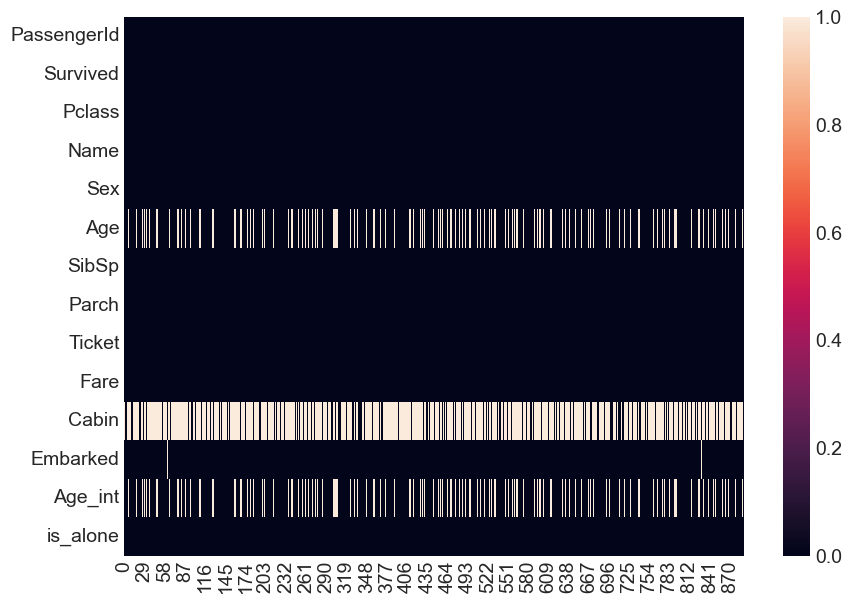

In [686]:
plt.figure(figsize=(10,7))
sns.heatmap(train_data.isna().T)

In [687]:
train_data.dropna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,54.0,1
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,4.0,0
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,58.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S,47.0,0
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S,33.0,1
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C,56.0,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1


In [688]:
train_data.dropna(axis=1)

,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,7.9250,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",male,0,0,373450,8.0500,1
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,0,0,211536,13.0000,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,0,0,112053,30.0000,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,1,2,W./C. 6607,23.4500,0
889,890,1,1,"Behr, Mr. Karl Howell",male,0,0,111369,30.0000,1


In [689]:
train_data.dropna(how="all", axis=1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [690]:
train_data.dropna(thresh=train_data.shape[0]//2, axis=1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1


In [691]:
train_data.dropna(subset=["Age"], axis=0)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q,39.0,0
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [692]:
# predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
# outcome = 'Survived'

# X = pd.get_dummies(train_data[predictors], drop_first=True)
# y = train_data[outcome]

# model_simple = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
# model_simple.fit(X,y,)

In [693]:
train_data_removed = train_data.dropna(thresh=train_data.shape[0]//2, axis=1)
train_data_removed

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1


In [694]:
train_data_removed.dropna(thresh=13, axis=0, inplace=True)
train_data_removed

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_25736/4115674139.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data_removed.dropna(thresh=13, axis=0, inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,Q,39.0,0
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1


<Axes: >

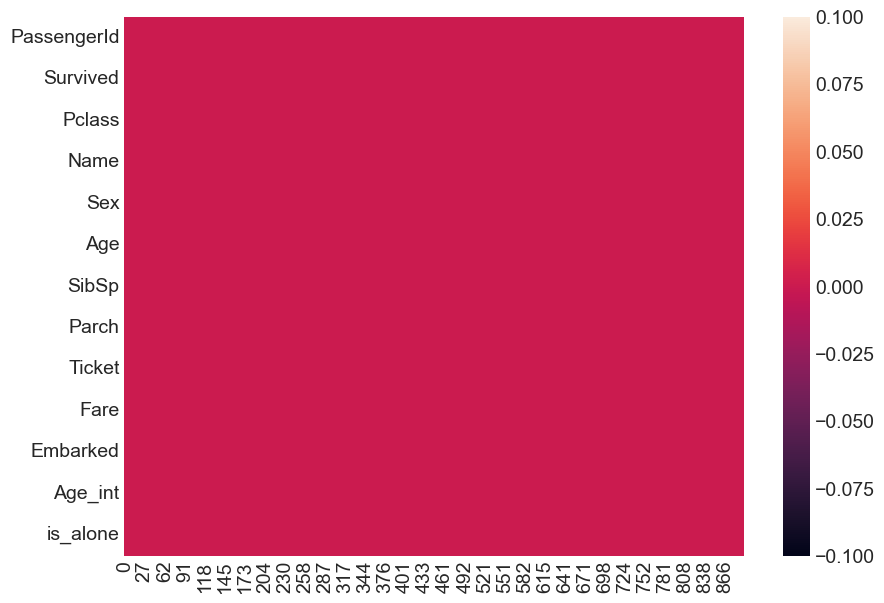

In [695]:
plt.figure(figsize=(10,7))
sns.heatmap(train_data_removed.isna().T)

In [696]:

train_data.isna().sum()#.sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Age_int        177
is_alone         0
dtype: int64

In [697]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [698]:
test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

<Axes: >

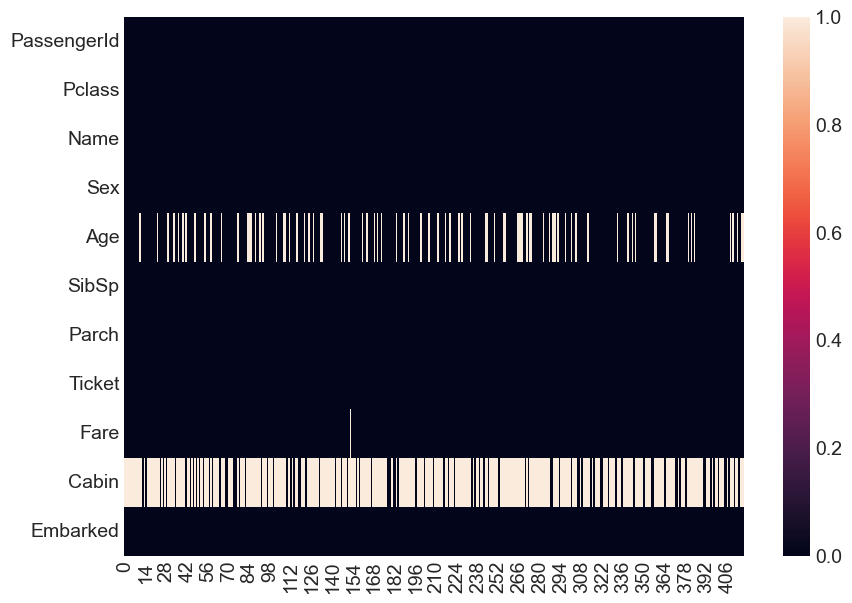

In [699]:
plt.figure(figsize=(10,7))
sns.heatmap(test_data.isna().T)

In [700]:
general_data = pd.concat([train_data,test_data])

print(test_data.Age.mean())
print(test_data.Age.median())

30.272590361445783
27.0


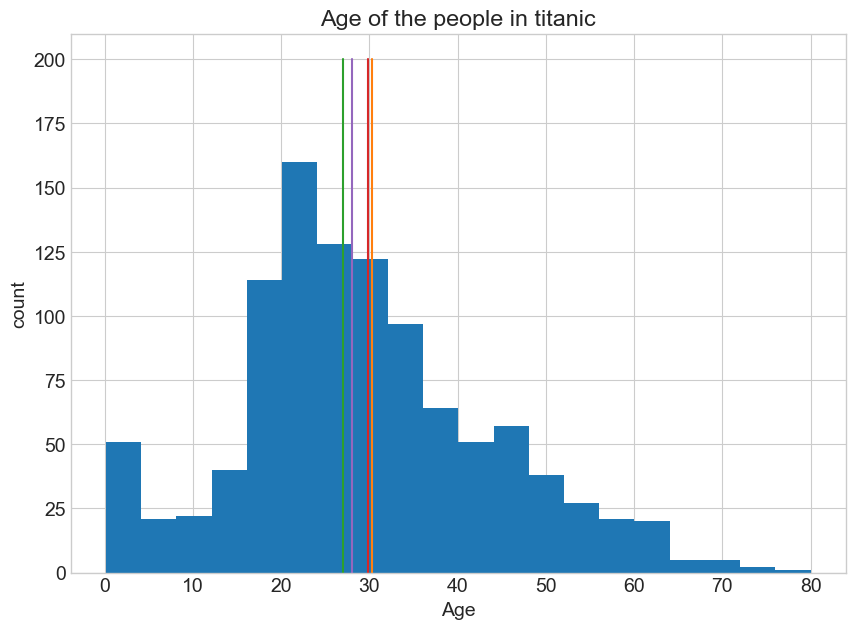

In [701]:
plt.figure(figsize=(10,7))


plt.hist(pd.concat([train_data.Age, test_data.Age]), bins=20)
plt.plot([test_data.Age.mean(), test_data.Age.mean()], [0, 200])
plt.plot([test_data.Age.median(), test_data.Age.median()], [0, 200])


plt.plot([general_data.Age.mean(), general_data.Age.mean()], [0, 200])
plt.plot([general_data.Age.median(), general_data.Age.median()], [0, 200])

plt.title("Age of the people in titanic")
plt.xlabel("Age")
plt.ylabel("count")

plt.show()

In [702]:
test_data.Age.isna().sum()

np.int64(86)

In [703]:
test_data["Age_filled"] = 0
test_data.loc[test_data.Age.isna(), "Age_filled"] = 1

test_data.Age.fillna(general_data.Age.median(), inplace=True)

test_data.Fare = test_data.Fare.fillna(general_data.Fare.median())

test_data

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_25736/1264029975.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data.Age.fillna(general_data.Age.median(), inplace=True)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_filled
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,28.0,0,0,A.5. 3236,8.0500,NaN,S,1
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0
416,1308,3,"Ware, Mr. Frederick",male,28.0,0,0,359309,8.0500,NaN,S,1


In [704]:
# test_data.Age.fillna(general_data.Age.median(), inplace=True)
# # test_data.Age = test_data.Age.fillna(general_data.Age.median())
# test_data

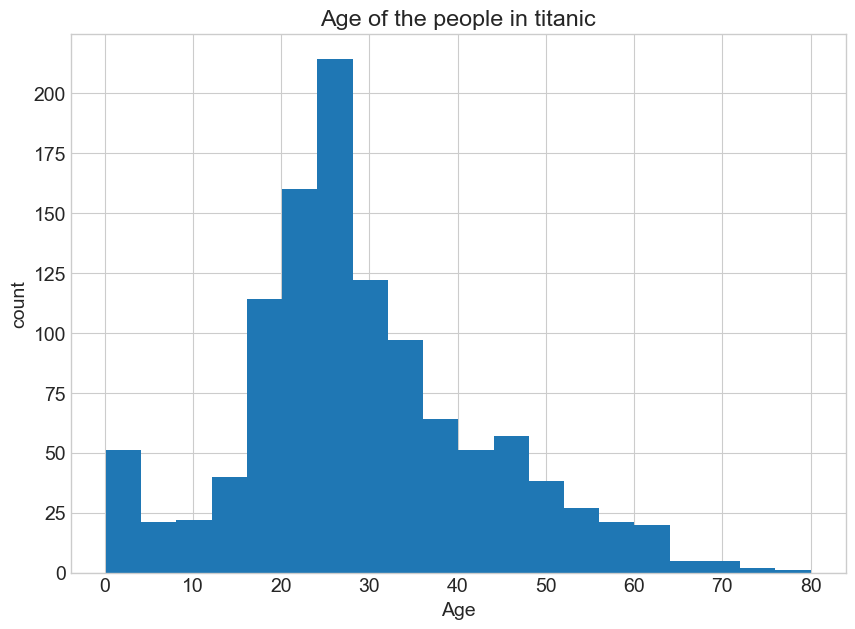

In [705]:
plt.figure(figsize=(10,7))


plt.hist(pd.concat([train_data.Age, test_data.Age]), bins=20)
# plt.plot([test_data.Age.mean(), test_data.Age.mean()], [0, 200])
# plt.plot([test_data.Age.median(), test_data.Age.median()], [0, 200])


# plt.plot([general_data.Age.mean(), general_data.Age.mean()], [0, 200])
# plt.plot([general_data.Age.median(), general_data.Age.median()], [0, 200])

plt.title("Age of the people in titanic")
plt.xlabel("Age")
plt.ylabel("count")

plt.show()

<Axes: >

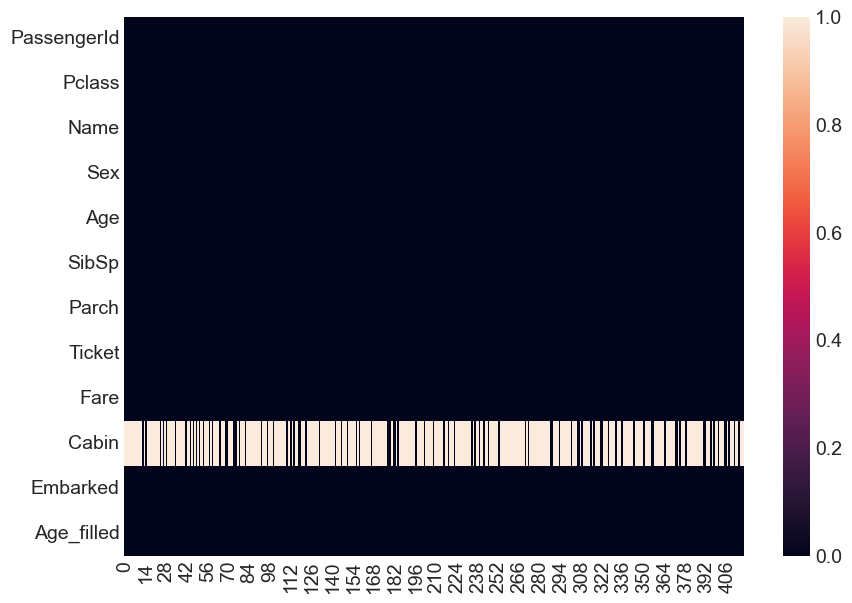

In [706]:
plt.figure(figsize=(10,7))
sns.heatmap(test_data.isna().T)

In [707]:

train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [708]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Age_int      714 non-null    float64
 13  is_alone     891 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 97.6+ KB


<Axes: >

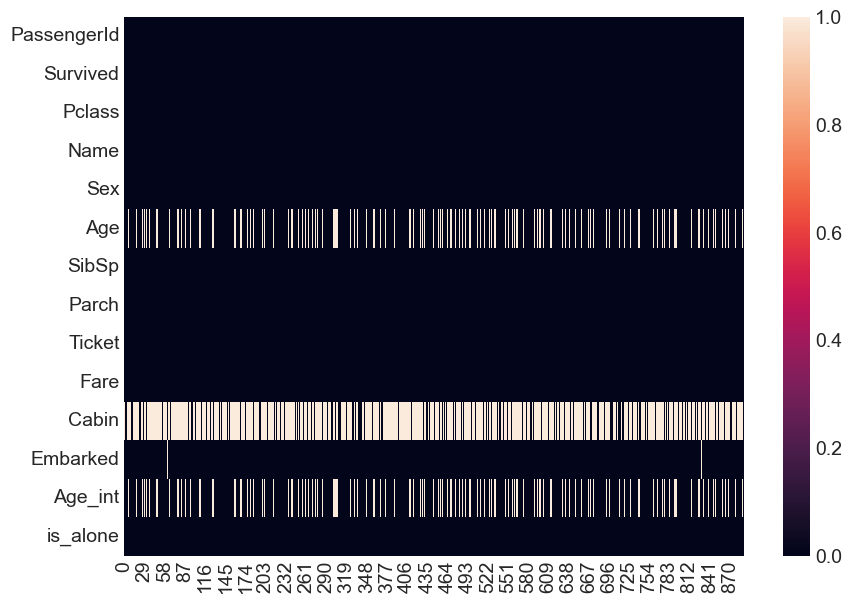

In [709]:
plt.figure(figsize=(10,7))
sns.heatmap(train_data.isna().T)

In [710]:
train_data_removed

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,Q,39.0,0
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1


In [711]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
outcome = 'Survived'

train_data_removed.is_alone = train_data_removed.is_alone.astype(int)


X = pd.get_dummies(train_data_removed[predictors], drop_first=True)
y = train_data_removed[outcome]

model_removed = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
model_removed.fit(X,y,)


/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_25736/4244844522.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data_removed.is_alone = train_data_removed.is_alone.astype(int)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1e+42
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [712]:
test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    object 
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
 11  Age_filled   418 non-null    int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 58.6+ KB


In [713]:
print_metrics(test_outcome.Survived, model_removed.predict(test_data_dummies), "Rows were Removed")

Metrics for Rows were Removed
-----------------------------
Accuracy: 0.8947368421052632
Precision: 0.8417721518987342
Recall: 0.875
Logloss: 3.7940687778018054
ROC-AUC: 0.8905075187969924




In [714]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked','is_alone']
outcome = 'Survived'


X = pd.get_dummies(train_data_removed[predictors], drop_first=True)
y = train_data_removed[outcome]


model_removed = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
model_removed.fit(X,y,)


test_data["is_alone"] = [1 if(parch == 0) and (sibsp == 0) else 0 for parch,sibsp in zip(test_data.Parch, test_data.SibSp)]

test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)
test_data_dummies

,Age,SibSp,Parch,Fare,is_alone,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,34.5,0,0,7.8292,1,False,True,True,True,False
1,47.0,1,0,7.0000,0,False,True,False,False,True
2,62.0,0,0,9.6875,1,True,False,True,True,False
3,27.0,0,0,8.6625,1,False,True,True,False,True
4,22.0,1,1,12.2875,0,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...
413,28.0,0,0,8.0500,1,False,True,True,False,True
414,39.0,0,0,108.9000,1,False,False,False,False,False
415,38.5,0,0,7.2500,1,False,True,True,False,True
416,28.0,0,0,8.0500,1,False,True,True,False,True


In [715]:
model_removed.coef_[0]
for key,value in enumerate(X.columns):
    print(f"{value}: {model_removed.coef_[0][key]}")

print("-"*50)

print_metrics(test_outcome.Survived, model_removed.predict(test_data_dummies), "Rows were Removed and 'is_alone' feature was used")

Age: -0.04271477469925315
SibSp: -0.5176843883543255
Parch: -0.16724123789110978
Fare: 0.0012006710449980408
is_alone: -0.5383626693875081
Pclass_2: -1.1708504781499167
Pclass_3: -2.313860675364895
Sex_male: -2.58593131216673
Embarked_Q: -0.677636652778554
Embarked_S: -0.3197699501720463
--------------------------------------------------
Metrics for Rows were Removed and 'is_alone' feature was used
-----------------------------
Accuracy: 0.8875598086124402
Precision: 0.8431372549019608
Recall: 0.8486842105263158
Logloss: 4.0527552853792015
ROC-AUC: 0.8792293233082707




In [716]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


<Axes: >

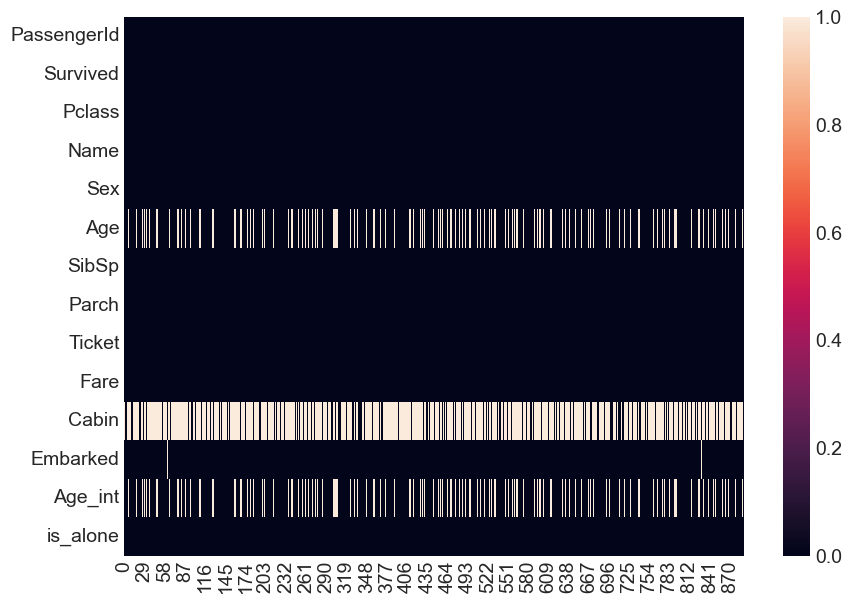

In [717]:
plt.figure(figsize=(10,7))
sns.heatmap(train_data.isna().T)

In [718]:
train_data["Age_filled"] = 0

train_data.loc[train_data.Age.isna(), "Age_filled"] = 1

train_data.is_alone = train_data.is_alone.astype(int)

train_data_recovered = train_data.drop(columns=["Cabin"])

train_data_recovered

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone,Age_filled
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S,NaN,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1,0


In [719]:


train_data_recovered.Age.fillna(general_data.Age.median(), inplace=True)

train_data_recovered.Embarked.fillna(general_data.Embarked.mode()[0], inplace=True)


train_data_recovered

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_25736/13664362.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data_recovered.Age.fillna(general_data.Age.median(), inplace=True)
/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_25736/13664362.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone,Age_filled
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,NaN,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1,0


<Axes: >

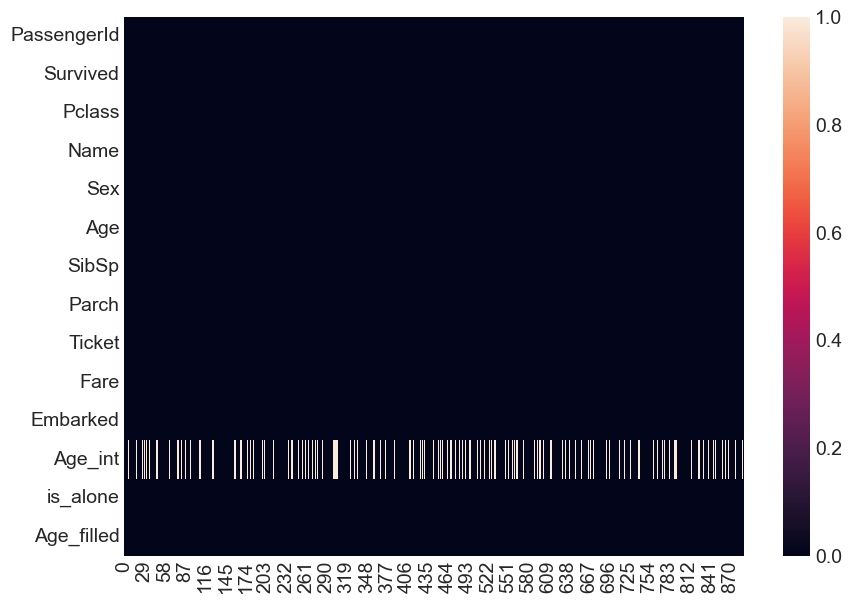

In [720]:
plt.figure(figsize=(10,7))
sns.heatmap(train_data_recovered.isna().T)

In [721]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors], drop_first=True)
y = train_data_recovered[outcome]


model_main = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
model_main.fit(X,y)

test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)
test_data_dummies

,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,34.5,0,0,7.8292,False,True,True,True,False
1,47.0,1,0,7.0000,False,True,False,False,True
2,62.0,0,0,9.6875,True,False,True,True,False
3,27.0,0,0,8.6625,False,True,True,False,True
4,22.0,1,1,12.2875,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...
413,28.0,0,0,8.0500,False,True,True,False,True
414,39.0,0,0,108.9000,False,False,False,False,False
415,38.5,0,0,7.2500,False,True,True,False,True
416,28.0,0,0,8.0500,False,True,True,False,True


In [722]:
print_metrics(test_outcome.Survived, model_main.predict(test_data_dummies), "Data was recovered")

Metrics for Data was recovered
-----------------------------
Accuracy: 0.9449760765550239
Precision: 0.9161290322580645
Recall: 0.9342105263157895
Logloss: 1.9832632247600348
ROC-AUC: 0.9426691729323308




In [723]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_filled,is_alone
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0,1
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,28.0,0,0,A.5. 3236,8.0500,NaN,S,1,1
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0,1
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0,1
416,1308,3,"Ware, Mr. Frederick",male,28.0,0,0,359309,8.0500,NaN,S,1,1


In [724]:
model_predictions = model_main.predict(test_data_dummies)
submit_file = pd.DataFrame({"PassengerId": test_data.PassengerId,
                            "Survived": model_predictions})

submit_file

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [725]:
submit_file.to_csv("data/submit_kaggle_file.csv", index=False)

In [726]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1,0


In [727]:
train_data.Ticket.str.extract("([0-9]+)")

,0
0,5
1,17599
2,2
3,113803
4,373450
...,...
886,211536
887,112053
888,6607
889,111369


In [728]:
train_data.Ticket.str.extract("(\d+[0-9]+)")

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_25736/2653487876.py:1: SyntaxWarning: invalid escape sequence '\d'
  train_data.Ticket.str.extract("(\d+[0-9]+)")


,0
0,21171
1,17599
2,3101282
3,113803
4,373450
...,...
886,211536
887,112053
888,6607
889,111369


In [729]:
train_data["Ticket_str"] = train_data.Ticket.str.extract("([A-Za-z\.\/0-9]+)")

train_data["Ticket_str"] = [np.nan if ticket.isdigit() else ticket for ticket in train_data["Ticket_str"]]

train_data

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_25736/2161196765.py:1: SyntaxWarning: invalid escape sequence '\.'
  train_data["Ticket_str"] = train_data.Ticket.str.extract("([A-Za-z\.\/0-9]+)")


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0,0,A/5
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0,0,PC
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1,0,STON/O2.
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0,0,NaN
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1,0,NaN
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1,0,NaN
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0,1,W./C.
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1,0,NaN


In [730]:
train_data["Ticket_int"] = train_data.Ticket.str.extract("(\d+[0-9]+)")

train_data

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_25736/37312392.py:1: SyntaxWarning: invalid escape sequence '\d'
  train_data["Ticket_int"] = train_data.Ticket.str.extract("(\d+[0-9]+)")


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str,Ticket_int
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0,0,A/5,21171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0,0,PC,17599
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1,0,STON/O2.,3101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0,0,NaN,113803
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1,0,NaN,373450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1,0,NaN,211536
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1,0,NaN,112053
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0,1,W./C.,6607
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1,0,NaN,111369


<Axes: >

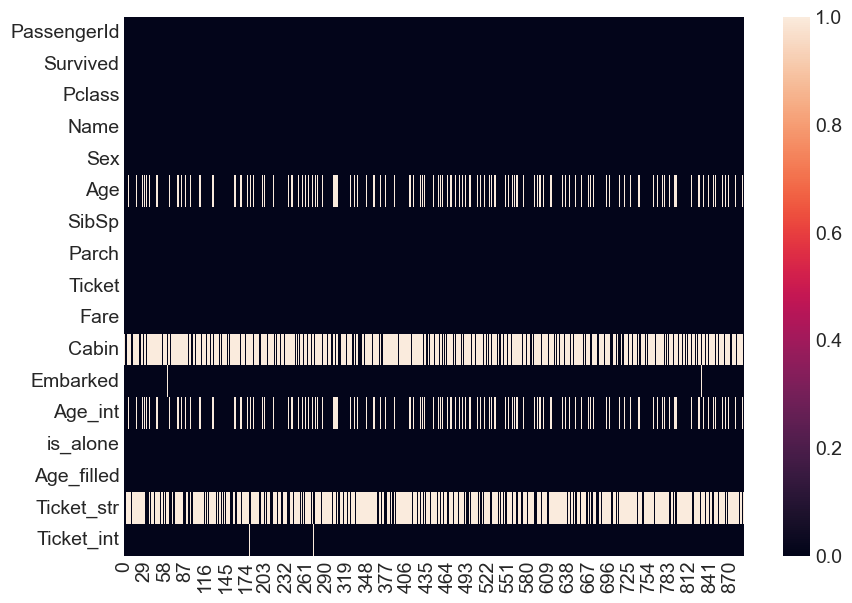

In [731]:
plt.figure(figsize=(10,7))
sns.heatmap(train_data.isna().T)

In [732]:
train_data.loc[train_data.Ticket_int.isna()]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str,Ticket_int
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S,36.0,1,0,LINE,NaN
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S,25.0,1,0,LINE,NaN
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S,19.0,1,0,LINE,NaN
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S,49.0,1,0,LINE,NaN
772,773,0,2,"Mack, Mrs. (Mary)",female,57.0,0,0,S.O./P.P. 3,10.5,E77,S,57.0,1,0,S.O./P.P.,NaN
841,842,0,2,"Mudd, Mr. Thomas Charles",male,16.0,0,0,S.O./P.P. 3,10.5,NaN,S,16.0,1,0,S.O./P.P.,NaN


In [733]:
train_data.loc[[772,841],["Ticket_int"]] = 3
train_data.loc[train_data.Ticket_int.isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str,Ticket_int
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S,36.0,1,0,LINE,NaN
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S,25.0,1,0,LINE,NaN
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S,19.0,1,0,LINE,NaN
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S,49.0,1,0,LINE,NaN


In [734]:
train_data.Ticket_int[~train_data.Ticket_int.isna()]


0        21171
1        17599
2      3101282
3       113803
4       373450
        ...   
886     211536
887     112053
888       6607
889     111369
890     370376
Name: Ticket_int, Length: 887, dtype: object

In [735]:
train_data.Ticket_int[~train_data.Ticket_int.isna()].astype(int).mean()

np.float64(298328.4171364149)

In [736]:
train_data.Ticket_int[~train_data.Ticket_int.isna()].mode()

0      1601
1      2343
2    347082
Name: Ticket_int, dtype: object

In [737]:
train_data.Ticket_int[~train_data.Ticket_int.isna()].value_counts()

Ticket_int
1601       7
347082     7
2343       7
3101295    6
2144       6
          ..
9234       1
19988      1
2693       1
17612      1
370376     1
Name: count, Length: 678, dtype: int64

In [738]:
train_data.Ticket_int = train_data.Ticket_int.fillna(train_data.Ticket_int[~train_data.Ticket_int.isna()].astype(int).median())
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str,Ticket_int
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0,0,A/5,21171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0,0,PC,17599
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1,0,STON/O2.,3101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0,0,NaN,113803
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1,0,NaN,373450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1,0,NaN,211536
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1,0,NaN,112053
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0,1,W./C.,6607
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1,0,NaN,111369


In [739]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked','Age_filled', "is_alone"]
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors], drop_first=True)
y = train_data_recovered[outcome]


model_recovered = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
model_recovered.fit(X,y)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1e+42
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [740]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_filled,is_alone
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0,1
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,28.0,0,0,A.5. 3236,8.0500,NaN,S,1,1
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0,1
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0,1
416,1308,3,"Ware, Mr. Frederick",male,28.0,0,0,359309,8.0500,NaN,S,1,1


In [741]:
test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)
print_metrics(test_outcome.Survived, model_recovered.predict(test_data_dummies), "Recovered data and added 'Age_filled','is_alone' features")

Metrics for Recovered data and added 'Age_filled','is_alone' features
-----------------------------
Accuracy: 0.9449760765550239
Precision: 0.910828025477707
Recall: 0.9407894736842105
Logloss: 1.9832632247600348
ROC-AUC: 0.9440789473684212




In [742]:
test_data["Ticket_int"] = test_data.Ticket.str.extract("(\d+[0-9]+)")

test_data.Ticket_int

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_25736/534419831.py:1: SyntaxWarning: invalid escape sequence '\d'
  test_data["Ticket_int"] = test_data.Ticket.str.extract("(\d+[0-9]+)")


0       330911
1       363272
2       240276
3       315154
4      3101298
        ...   
413       3236
414      17758
415    3101262
416     359309
417       2668
Name: Ticket_int, Length: 418, dtype: object

In [743]:
pd.concat([train_data, test_data]).reset_index()

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str,Ticket_int
0,0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0,0,A/5,21171
1,1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0,0,PC,17599
2,2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1,0,STON/O2.,3101282
3,3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0,0,NaN,113803
4,4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1,0,NaN,373450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,413,1305,NaN,3,"Spector, Mr. Woolf",male,28.0,0,0,A.5. 3236,8.0500,NaN,S,NaN,1,1,NaN,3236
1305,414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,NaN,1,0,NaN,17758
1306,415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,NaN,1,0,NaN,3101262
1307,416,1308,NaN,3,"Ware, Mr. Frederick",male,28.0,0,0,359309,8.0500,NaN,S,NaN,1,1,NaN,359309


In [744]:
train_data_recovered

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone,Age_filled
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,NaN,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1,0


In [745]:
train_data_recovered["Ticket_int"] = train_data_recovered.Ticket.str.extract("(\d+[0-9]+)")
train_data_recovered

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_25736/1589571751.py:1: SyntaxWarning: invalid escape sequence '\d'
  train_data_recovered["Ticket_int"] = train_data_recovered.Ticket.str.extract("(\d+[0-9]+)")


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone,Age_filled,Ticket_int
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0,0,21171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0,0,17599
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1,0,3101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0,0,113803
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1,0,373450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1,0,211536
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1,0,112053
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,NaN,0,1,6607
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1,0,111369


In [746]:
train_data_recovered.Ticket_int.isna().sum()

np.int64(6)

In [747]:
test_data.Ticket_int.isna().sum()

np.int64(2)

In [748]:
mean_ticket_int = train_data_recovered.loc[~train_data_recovered.Ticket_int.isna()].Ticket_int.astype(int).mean()
median_ticket_int = train_data_recovered.loc[~train_data_recovered.Ticket_int.isna()].Ticket_int.astype(int).median()

print(mean_ticket_int)
print(median_ticket_int)

299002.5988700565
112379.0


In [749]:
train_data_recovered.Ticket_int.fillna(median_ticket_int, inplace=True)
train_data_recovered

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_25736/1435883998.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data_recovered.Ticket_int.fillna(median_ticket_int, inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone,Age_filled,Ticket_int
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0,0,21171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0,0,17599
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1,0,3101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0,0,113803
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1,0,373450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1,0,211536
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1,0,112053
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,NaN,0,1,6607
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1,0,111369


In [750]:
train_data_recovered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
 11  Age_int      714 non-null    float64
 12  is_alone     891 non-null    int64  
 13  Age_filled   891 non-null    int64  
 14  Ticket_int   891 non-null    object 
dtypes: float64(3), int64(6), object(6)
memory usage: 104.5+ KB


In [751]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 0 to 417
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    object 
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
 11  Age_filled   418 non-null    int64  
 12  is_alone     418 non-null    int64  
 13  Ticket_int   416 non-null    object 
dtypes: float64(2), int64(5), object(7)
memory usage: 65.1+ KB


In [752]:
test_data.Ticket_int.fillna(median_ticket_int, inplace=True)
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_filled,is_alone,Ticket_int
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0,1,330911
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0,0,363272
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0,1,240276
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0,1,315154
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0,0,3101298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,28.0,0,0,A.5. 3236,8.0500,NaN,S,1,1,3236
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0,1,17758
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0,1,3101262
416,1308,3,"Ware, Mr. Frederick",male,28.0,0,0,359309,8.0500,NaN,S,1,1,359309


In [753]:
train_data_recovered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
 11  Age_int      714 non-null    float64
 12  is_alone     891 non-null    int64  
 13  Age_filled   891 non-null    int64  
 14  Ticket_int   891 non-null    object 
dtypes: float64(3), int64(6), object(6)
memory usage: 104.5+ KB


In [754]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 0 to 417
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    object 
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
 11  Age_filled   418 non-null    int64  
 12  is_alone     418 non-null    int64  
 13  Ticket_int   418 non-null    object 
dtypes: float64(2), int64(5), object(7)
memory usage: 65.1+ KB


In [755]:
test_data.Ticket_int = test_data.Ticket_int.astype(int)
train_data_recovered.Ticket_int = train_data_recovered.Ticket_int.astype(int)


In [756]:
train_data_recovered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
 11  Age_int      714 non-null    float64
 12  is_alone     891 non-null    int64  
 13  Age_filled   891 non-null    int64  
 14  Ticket_int   891 non-null    int64  
dtypes: float64(3), int64(7), object(5)
memory usage: 104.5+ KB


In [757]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 0 to 417
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    object 
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
 11  Age_filled   418 non-null    int64  
 12  is_alone     418 non-null    int64  
 13  Ticket_int   418 non-null    int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 65.1+ KB


In [758]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',"Ticket_int","is_alone","Age_filled"]
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors], drop_first=True)
y = train_data_recovered[outcome]


model_recovered_new_features = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
model_recovered_new_features.fit(X,y)

test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)

print_metrics(test_outcome.Survived, model_recovered_new_features.predict(test_data_dummies), 'Added "Ticket_int","is_alone","Age_filled" feature')

Metrics for Added "Ticket_int","is_alone","Age_filled" feature
-----------------------------
Accuracy: 0.65311004784689
Precision: 0.547945205479452
Recall: 0.2631578947368421
Logloss: 12.503181199574131
ROC-AUC: 0.569548872180451




In [759]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',"Ticket_int","is_alone","Age_filled"]
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors], drop_first=True)
y = train_data_recovered[outcome]


model_recovered_new_features = LogisticRegression(penalty='l1', C=1e42, solver='liblinear')
model_recovered_new_features.fit(X,y)

test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)

print_metrics(test_outcome.Survived, model_recovered_new_features.predict(test_data_dummies), 'Added "Ticket_int","is_alone","Age_filled" features, l1')

Metrics for Added "Ticket_int","is_alone","Age_filled" features, l1
-----------------------------
Accuracy: 0.9354066985645934
Precision: 0.9032258064516129
Recall: 0.9210526315789473
Logloss: 2.3281785681965625
ROC-AUC: 0.9323308270676692




In [760]:
train_data.Cabin.isna().sum()/(train_data.Cabin.isna().sum() + train_data.Cabin.count())

np.float64(0.7710437710437711)

In [761]:
test_data.Cabin.isna().sum()/(test_data.Cabin.isna().sum() + test_data.Cabin.count())


np.float64(0.7822966507177034)

In [762]:
# train_data["Cabin_str"] =
train_data["Cabin_str"] = train_data.Cabin.str.extract("([a-zA-Z]+)")
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str,Ticket_int,Cabin_str
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0,0,A/5,21171,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0,0,PC,17599,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1,0,STON/O2.,3101282,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0,0,NaN,113803,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1,0,NaN,373450,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1,0,NaN,211536,NaN
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1,0,NaN,112053,B
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0,1,W./C.,6607,NaN
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1,0,NaN,111369,C


In [763]:
test_data["Cabin_str"] = test_data.Cabin.str.extract("([a-zA-Z]+)")
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_filled,is_alone,Ticket_int,Cabin_str
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0,1,330911,NaN
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0,0,363272,NaN
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0,1,240276,NaN
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0,1,315154,NaN
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0,0,3101298,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,28.0,0,0,A.5. 3236,8.0500,NaN,S,1,1,3236,NaN
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0,1,17758,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0,1,3101262,NaN
416,1308,3,"Ware, Mr. Frederick",male,28.0,0,0,359309,8.0500,NaN,S,1,1,359309,NaN


In [764]:
train_data.Cabin_str.value_counts()

Cabin_str
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

In [765]:
train_data_recovered["Cabin_str"] = train_data.Cabin_str
train_data_recovered.loc[train_data_recovered.Cabin_str == "T", "Cabin_str"] = "C"
train_data_recovered.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone,Age_filled,Ticket_int,Cabin_str
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0,0,21171,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0,0,17599,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1,0,3101282,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0,0,113803,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1,0,373450,NaN


In [766]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',"Cabin_str"]
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors], drop_first=True)
y = train_data_recovered[outcome]


model_recovered_new_features = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
model_recovered_new_features.fit(X,y)

test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)

print_metrics(test_outcome.Survived, model_recovered_new_features.predict(test_data_dummies), 'Added "Cabin_str"')

Metrics for Added "Cabin_str"
-----------------------------
Accuracy: 0.9282296650717703
Precision: 0.8860759493670886
Recall: 0.9210526315789473
Logloss: 2.5868650757739586
ROC-AUC: 0.9266917293233082




In [767]:
test_data.Cabin_str.value_counts()

Cabin_str
C    35
B    18
D    13
E     9
F     8
A     7
G     1
Name: count, dtype: int64

In [768]:
pd.DataFrame({"coef": model_recovered_new_features.coef_[0],
              "name": X.columns})

,coef,name
0,-0.040542,Age
1,-0.325747,SibSp
2,-0.103044,Parch
3,0.002787,Fare
4,-0.487609,Pclass_2
5,-1.654336,Pclass_3
6,-2.734587,Sex_male
7,-0.108134,Embarked_Q
8,-0.507073,Embarked_S
9,0.686660,Cabin_str_B


In [769]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors])
y = train_data_recovered[outcome]

test_data_dummies = pd.get_dummies(test_data[predictors])


scalar = StandardScaler()
scalar.fit(X)

X_std = scalar.transform(X)
test_data_scalared = scalar.transform(test_data_dummies)


model_knn = KNeighborsClassifier(n_neighbors=15)
model_knn.fit(X_std,y)


print_metrics(test_outcome.Survived, model_knn.predict(test_data_scalared), 'KNN model')

Metrics for KNN model
-----------------------------
Accuracy: 0.8947368421052632
Precision: 0.921875
Recall: 0.7763157894736842
Logloss: 3.7940687778018054
ROC-AUC: 0.869360902255639




In [770]:
train_data["KNN_prob"] = model_knn.predict_proba(X_std)[:,1]
train_data_recovered["KNN_prob"] = model_knn.predict_proba(X_std)[:,1]
test_data["KNN_prob"] = model_knn.predict_proba(test_data_scalared)[:,1]
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str,Ticket_int,Cabin_str,KNN_prob
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0,0,A/5,21171,NaN,0.133333
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0,0,PC,17599,C,1.000000
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1,0,STON/O2.,3101282,NaN,0.466667
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0,0,NaN,113803,C,1.000000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1,0,NaN,373450,NaN,0.066667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1,0,NaN,211536,NaN,0.066667
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1,0,NaN,112053,B,1.000000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0,1,W./C.,6607,NaN,0.400000
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1,0,NaN,111369,C,0.466667


In [771]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', "KNN_prob"]
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors], drop_first=True)
y = train_data_recovered[outcome]


model_recovered_new_features = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
model_recovered_new_features.fit(X,y)

test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)

print_metrics(test_outcome.Survived, model_recovered_new_features.predict(test_data_dummies), 'Added "KNN_prob"')

Metrics for Added "KNN_prob"
-----------------------------
Accuracy: 0.861244019138756
Precision: 0.7974683544303798
Recall: 0.8289473684210527
Logloss: 5.001272479829653
ROC-AUC: 0.8543233082706767




# DECISION TREE MODEL

In [772]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split


predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors])
y = train_data_recovered[outcome]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

model_tree = DecisionTreeClassifier(random_state=1, criterion='entropy', min_impurity_decrease=0.003)
model_tree.fit(X, y)



test_data_dummies = pd.get_dummies(test_data[predictors])

print_metrics(test_outcome.Survived, model_tree.predict(test_data_dummies), 'Test set')
print_metrics(y_test, model_tree.predict(X_test), 'Train set')

Metrics for Test set
-----------------------------
Accuracy: 0.8349282296650717
Precision: 0.8217054263565892
Recall: 0.6973684210526315
Logloss: 5.949789674280105
ROC-AUC: 0.8054511278195489


Metrics for Train set
-----------------------------
Accuracy: 0.8766816143497758
Precision: 0.9133333333333333
Recall: 0.7653631284916201
Logloss: 4.44484514888216
ROC-AUC: 0.8583369949574207




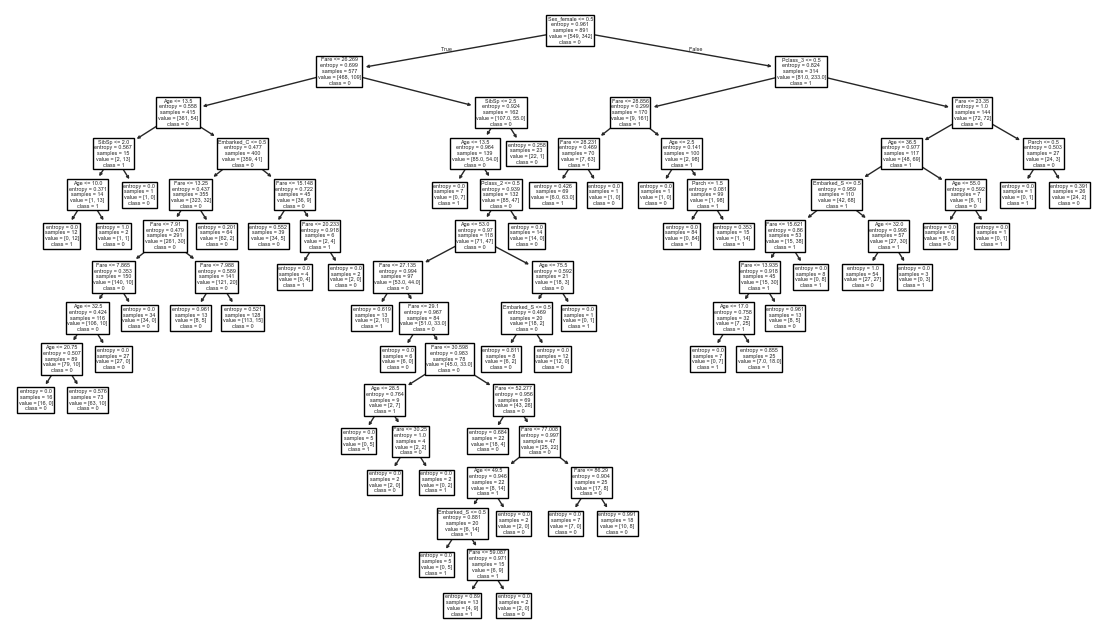

In [773]:
from dmba import textDecisionTree
from sklearn.tree import plot_tree

# print(textDecisionTree(model_tree))

plt.figure(figsize=(14,8))
plot_tree(model_tree, feature_names=X.columns, class_names=[str(cls) for cls in model_tree.classes_], filled=False)
plt.show()


In [774]:

predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',"KNN_prob"]
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors])
y = train_data_recovered[outcome]


model_tree = DecisionTreeClassifier(random_state=1)
model_tree.fit(X, y)



test_data_dummies = pd.get_dummies(test_data[predictors])

print_metrics(test_outcome.Survived, model_tree.predict(test_data_dummies), 'Tree model, "KNN_prob"')

Metrics for Tree model, "KNN_prob"
-----------------------------
Accuracy: 0.784688995215311
Precision: 0.691358024691358
Recall: 0.7368421052631579
Logloss: 7.760595227321875
ROC-AUC: 0.7744360902255639




In [775]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors])
y = train_data_recovered[outcome]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)


model_tree = DecisionTreeClassifier(random_state=1, criterion='entropy', min_impurity_decrease=0.003, max_depth=3, max_leaf_nodes=6)
model_tree.fit(X, y)


test_data_dummies = pd.get_dummies(test_data[predictors])

print_metrics(test_outcome.Survived, model_tree.predict(test_data_dummies), 'Test set')
print_metrics(y_test, model_tree.predict(X_test), 'Train set')

Metrics for Test set
-----------------------------
Accuracy: 0.9617224880382775
Precision: 0.9358974358974359
Recall: 0.9605263157894737
Logloss: 1.3796613737461112
ROC-AUC: 0.9614661654135338


Metrics for Train set
-----------------------------
Accuracy: 0.8139013452914798
Precision: 0.8037974683544303
Recall: 0.7094972067039106
Logloss: 6.707675406494895
ROC-AUC: 0.7966961688950265




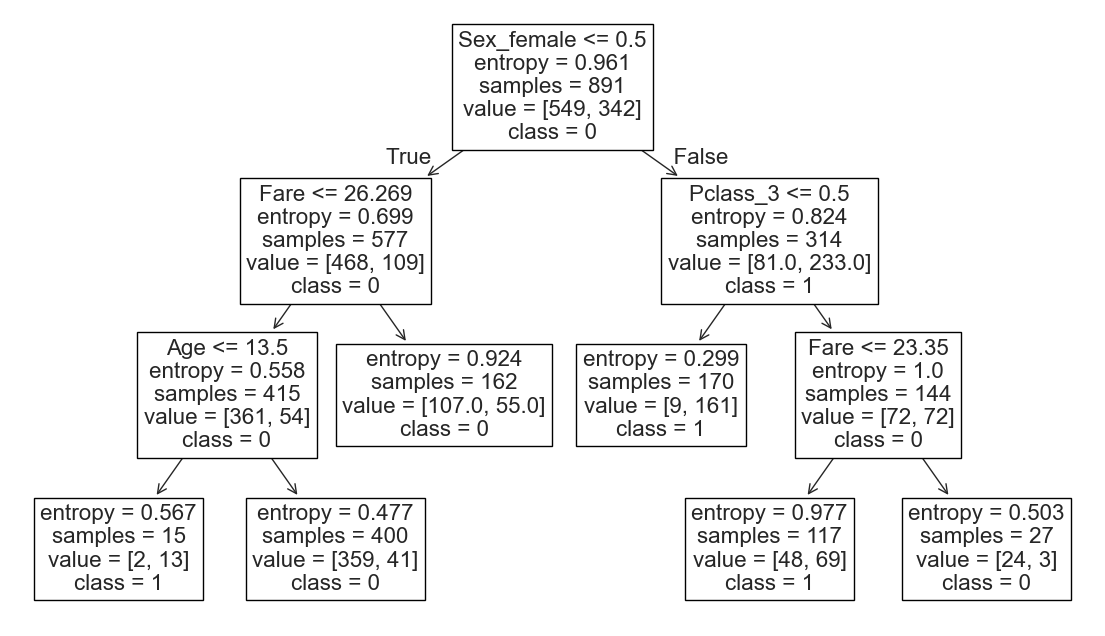

In [776]:

plt.figure(figsize=(14,8))
plot_tree(model_tree, feature_names=X.columns, class_names=[str(cls) for cls in model_tree.classes_], filled=False)
plt.show()

In [777]:
model_predictions = model_tree.predict(test_data_dummies)
submit_file = pd.DataFrame({"PassengerId": test_data.PassengerId,
                            "Survived": model_predictions})

submit_file

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [778]:
submit_file.to_csv("data/submit_kaggle_file.csv", index=False)

In [779]:
from sklearn.ensemble import RandomForestClassifier


predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors])
y = train_data_recovered[outcome]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)


model_rf = RandomForestClassifier(random_state=1, criterion='entropy', min_impurity_decrease=0.003, max_depth=3, max_leaf_nodes=6)
model_rf.fit(X, y)


test_data_dummies = pd.get_dummies(test_data[predictors])

print_metrics(test_outcome.Survived, model_rf.predict(test_data_dummies), 'Test set')
print_metrics(y_test, model_rf.predict(X_test), 'Train set')


Metrics for Test set
-----------------------------
Accuracy: 0.9880382775119617
Precision: 1.0
Recall: 0.9671052631578947
Logloss: 0.4311441792956599
ROC-AUC: 0.9835526315789473


Metrics for Train set
-----------------------------
Accuracy: 0.8071748878923767
Precision: 0.803921568627451
Recall: 0.6871508379888268
Logloss: 6.950121505524832
ROC-AUC: 0.7873956437135144




In [780]:
model_predictions = model_rf.predict(test_data_dummies)
submit_file = pd.DataFrame({"PassengerId": test_data.PassengerId,
                            "Survived": model_predictions})

submit_file

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [781]:
submit_file.to_csv("data/submit_kaggle_file.csv", index=False)


In [782]:
from sklearn.ensemble import RandomForestClassifier


predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors])
y = train_data_recovered[outcome]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model_rf = RandomForestClassifier(random_state=1, criterion='gini', max_depth=3, max_leaf_nodes=7, min_samples_leaf=26, n_estimators=500)
model_rf.fit(X_train, y_train)


test_data_dummies = pd.get_dummies(test_data[predictors])

# print_metrics(test_outcome.Survived, model_rf.predict(test_data_dummies), 'Test set')
print_metrics(y_test, model_rf.predict(X_test), 'Test set')

Metrics for Test set
-----------------------------
Accuracy: 0.7877094972067039
Precision: 0.7727272727272727
Recall: 0.6891891891891891
Logloss: 7.651725300482972
ROC-AUC: 0.7731660231660231




In [783]:

rf_all = RandomForestClassifier(n_estimators=500, random_state=1)
rf_all.fit(X, y)

rf_all_entropy = RandomForestClassifier(n_estimators=500, random_state=1,
                                        criterion='entropy')
print(rf_all_entropy.fit(X, y))

RandomForestClassifier(criterion='entropy', n_estimators=500, random_state=1)


In [784]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from collections import defaultdict


rf = RandomForestClassifier(n_estimators=500)
scores = defaultdict(list)
 
# crossvalidate the scores on a number of different random splits of the data
for _ in range(3):
    train_X, valid_X, train_y, valid_y = train_test_split(X, y, 
                                                          test_size=0.3)
    rf.fit(train_X, train_y)
    acc = metrics.accuracy_score(valid_y, rf.predict(valid_X))
    for column in X.columns:
        X_t = valid_X.copy()
        X_t[column] = np.random.permutation(X_t[column].values)
        shuff_acc = metrics.accuracy_score(valid_y, rf.predict(X_t))
        scores[column].append((acc-shuff_acc)/acc)
print('Features sorted by their score:')
print(sorted([(round(np.mean(score), 4), feat) for
              feat, score in scores.items()], reverse=True))



Features sorted by their score:
[(np.float64(0.0681), 'Sex_male'), (np.float64(0.0514), 'Age'), (np.float64(0.0482), 'Sex_female'), (np.float64(0.0471), 'Pclass_3'), (np.float64(0.0362), 'Fare'), (np.float64(0.0105), 'Parch'), (np.float64(0.0032), 'Embarked_Q'), (np.float64(-0.0), 'SibSp'), (np.float64(0.0), 'Embarked_C'), (np.float64(-0.0018), 'Pclass_1'), (np.float64(-0.0061), 'Pclass_2'), (np.float64(-0.012), 'Embarked_S')]


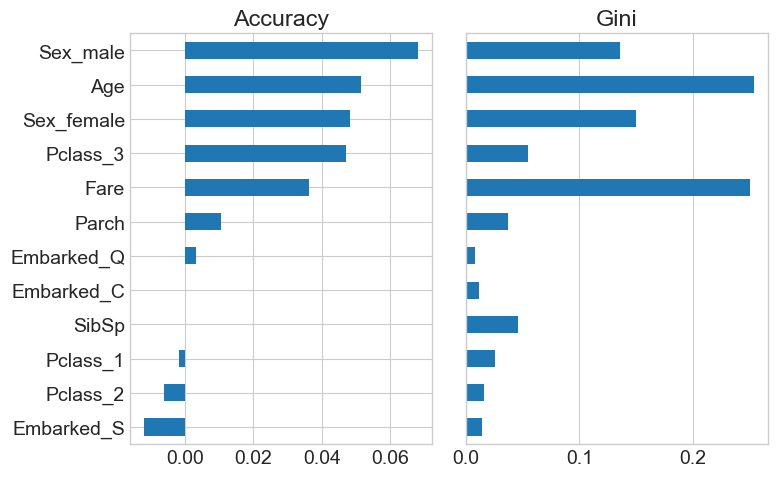

In [785]:
importances = rf_all.feature_importances_

df = pd.DataFrame({
    'feature': X.columns, 
    'Accuracy decrease': [np.mean(scores[column]) for column in 
                         X.columns],
    'Gini decrease': rf_all.feature_importances_, 
    'Entropy decrease': rf_all_entropy.feature_importances_,
})
df = df.sort_values('Accuracy decrease')

fig, axes = plt.subplots(ncols=2, figsize=(8, 5))
ax = df.plot(kind='barh', x='feature', y='Accuracy decrease', 
             legend=False, ax=axes[0], title="Accuracy")
ax.set_ylabel('')

ax = df.plot(kind='barh', x='feature', y='Gini decrease', 
             legend=False, ax=axes[1], title="Gini")
ax.set_ylabel('')
ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

# Correct creating models (without test_outcome)

In [786]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str,Ticket_int,Cabin_str,KNN_prob
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0,0,A/5,21171,NaN,0.133333
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0,0,PC,17599,C,1.000000
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1,0,STON/O2.,3101282,NaN,0.466667
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0,0,NaN,113803,C,1.000000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1,0,NaN,373450,NaN,0.066667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1,0,NaN,211536,NaN,0.066667
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1,0,NaN,112053,B,1.000000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0,1,W./C.,6607,NaN,0.400000
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1,0,NaN,111369,C,0.466667


In [787]:
# Logistic Regression
def logistic_model_print_metrics(predictors):
    outcome = 'Survived'

    X = pd.get_dummies(train_data_recovered[predictors], drop_first=True)
    y = train_data_recovered[outcome]

    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, shuffle=True, test_size=0.2)

    model_main = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
    model_main.fit(X_train,y_train)

    print_metrics(y_test, model_main.predict(X_test), "test set")
    print_metrics(y_train, model_main.predict(X_train), "train set")

logistic_model_print_metrics(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'])

Metrics for test set
-----------------------------
Accuracy: 0.7988826815642458
Precision: 0.7794117647058824
Recall: 0.7162162162162162
Logloss: 7.249002916247025
ROC-AUC: 0.7866795366795367


Metrics for train set
-----------------------------
Accuracy: 0.8075842696629213
Precision: 0.7763713080168776
Recall: 0.6865671641791045
Logloss: 6.935365890883497
ROC-AUC: 0.7835988974048675




In [788]:
logistic_model_print_metrics(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', "is_alone"])

Metrics for test set
-----------------------------
Accuracy: 0.7932960893854749
Precision: 0.7761194029850746
Recall: 0.7027027027027027
Logloss: 7.450364108364997
ROC-AUC: 0.7799227799227799


Metrics for train set
-----------------------------
Accuracy: 0.8089887640449438
Precision: 0.775
Recall: 0.6940298507462687
Logloss: 6.884742782190917
ROC-AUC: 0.7862041145623235




In [789]:
logistic_model_print_metrics(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', "Cabin_str"])

Metrics for test set
-----------------------------
Accuracy: 0.7932960893854749
Precision: 0.7605633802816901
Recall: 0.7297297297297297
Logloss: 7.450364108364997
ROC-AUC: 0.783912483912484


Metrics for train set
-----------------------------
Accuracy: 0.8202247191011236
Precision: 0.782258064516129
Recall: 0.7238805970149254
Logloss: 6.479757912650275
ROC-AUC: 0.8011294876966518




In [790]:
logistic_model_print_metrics(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', "Age_filled"])

Metrics for test set
-----------------------------
Accuracy: 0.8100558659217877
Precision: 0.7941176470588235
Recall: 0.7297297297297297
Logloss: 6.846280532011079
ROC-AUC: 0.7981981981981983


Metrics for train set
-----------------------------
Accuracy: 0.8075842696629213
Precision: 0.7763713080168776
Recall: 0.6865671641791045
Logloss: 6.935365890883497
ROC-AUC: 0.7835988974048675




In [791]:
logistic_model_print_metrics(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', "KNN_prob"])

Metrics for test set
-----------------------------
Accuracy: 0.8212290502793296
Precision: 0.8181818181818182
Recall: 0.7297297297297297
Logloss: 6.443558147775134
ROC-AUC: 0.8077220077220078


Metrics for train set
-----------------------------
Accuracy: 0.824438202247191
Precision: 0.8235294117647058
Recall: 0.6791044776119403
Logloss: 6.327888586572533
ROC-AUC: 0.7956333198870512




In [792]:
logistic_model_print_metrics(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', "Age_filled", "KNN_prob"])

Metrics for test set
-----------------------------
Accuracy: 0.8435754189944135
Precision: 0.8285714285714286
Recall: 0.7837837837837838
Logloss: 5.638113379303242
ROC-AUC: 0.8347490347490346


Metrics for train set
-----------------------------
Accuracy: 0.8300561797752809
Precision: 0.8209606986899564
Recall: 0.7014925373134329
Logloss: 6.125396151802213
ROC-AUC: 0.8045750974855452




In [793]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', "Age_filled", "KNN_prob"]
outcome = 'Survived'

X = pd.get_dummies(train_data_recovered[predictors], drop_first=True)
y = train_data_recovered[outcome]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, shuffle=True, test_size=0.2)

model_main = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
model_main.fit(X_train,y_train)

print_metrics(y_test, model_main.predict(X_test), "test set")
print_metrics(y_train, model_main.predict(X_train), "train set")

Metrics for test set
-----------------------------
Accuracy: 0.8435754189944135
Precision: 0.8285714285714286
Recall: 0.7837837837837838
Logloss: 5.638113379303242
ROC-AUC: 0.8347490347490346


Metrics for train set
-----------------------------
Accuracy: 0.8300561797752809
Precision: 0.8209606986899564
Recall: 0.7014925373134329
Logloss: 6.125396151802213
ROC-AUC: 0.8045750974855452




In [794]:
test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)
prediction = model_main.predict(test_data_dummies)

submit_file = pd.DataFrame({"PassengerId": test_data.PassengerId,
              "Survived": prediction})

submit_file.to_csv("data/submit_kaggle_file.csv", index=False)

# Random Forest

In [795]:
from sklearn.ensemble import RandomForestClassifier


predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', "Age_filled", "KNN_prob"]
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors])
y = train_data_recovered[outcome]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


model_rf = RandomForestClassifier(random_state=1, criterion='entropy', max_depth=7, max_leaf_nodes=500, min_samples_leaf=4,  n_estimators=500)
model_rf.fit(X_train, y_train)

print_metrics(y_test, model_rf.predict(X_test), 'Test set')
print_metrics(y_train, model_rf.predict(X_train), 'Train set')

Metrics for Test set
-----------------------------
Accuracy: 0.8379888268156425
Precision: 0.8571428571428571
Recall: 0.7297297297297297
Logloss: 5.839474571421214
ROC-AUC: 0.822007722007722


Metrics for Train set
-----------------------------
Accuracy: 0.8651685393258427
Precision: 0.9095238095238095
Recall: 0.7126865671641791
Logloss: 4.859818434487706
ROC-AUC: 0.8349468871856931




# Decision Tree

In [796]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',"Age_filled", "KNN_prob"]
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors])
y = train_data_recovered[outcome]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model_tree = DecisionTreeClassifier(random_state=1, criterion='entropy', max_depth=6, min_samples_leaf=5, max_leaf_nodes=6)
model_tree.fit(X_train, y_train)


print_metrics(y_test, model_tree.predict(X_test), 'Test set')
print_metrics(y_train,model_tree.predict(X_train), 'Train set')

Metrics for Test set
-----------------------------
Accuracy: 0.8212290502793296
Precision: 0.8387096774193549
Recall: 0.7027027027027027
Logloss: 6.443558147775134
ROC-AUC: 0.8037323037323038


Metrics for Train set
-----------------------------
Accuracy: 0.8258426966292135
Precision: 0.8529411764705882
Recall: 0.6492537313432836
Logloss: 6.277265477879953
ROC-AUC: 0.790843081887858




# XGBoost

In [797]:
from xgboost import XGBClassifier


predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',"Age_filled", "KNN_prob"]
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors])
y = train_data_recovered[outcome]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model_XGB = XGBClassifier(objective='binary:logistic', n_estimators=500,
                            max_depth=6, learning_rate=0.5,
                            subsample=0.63, random_state=1)
model_XGB.fit(X_train, y_train)


print_metrics(y_test, model_XGB.predict(X_test), 'Test set')
print_metrics(y_train,model_XGB.predict(X_train), 'Train set')

Metrics for Test set
-----------------------------
Accuracy: 0.8044692737430168
Precision: 0.7468354430379747
Recall: 0.7972972972972973
Logloss: 7.047641724129053
ROC-AUC: 0.8034105534105535


Metrics for Train set
-----------------------------
Accuracy: 0.9789325842696629
Precision: 0.9809885931558935
Recall: 0.9626865671641791
Logloss: 0.7593466303887042
ROC-AUC: 0.9757126529514589




In [798]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',"Age_filled", "KNN_prob"]
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors])
y = train_data_recovered[outcome]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model_XGB_penalize = XGBClassifier(objective='binary:logistic', n_estimators=500,
                            max_depth=6, reg_lambda=1000, learning_rate=1.3,
                            subsample=0.5, random_state=1)
model_XGB_penalize.fit(X_train, y_train)


print_metrics(y_test, model_XGB_penalize.predict(X_test), 'Test set')
print_metrics(y_train,model_XGB_penalize.predict(X_train), 'Train set')

Metrics for Test set
-----------------------------
Accuracy: 0.8379888268156425
Precision: 0.8169014084507042
Recall: 0.7837837837837838
Logloss: 5.839474571421214
ROC-AUC: 0.82998712998713


Metrics for Train set
-----------------------------
Accuracy: 0.8735955056179775
Precision: 0.8903508771929824
Recall: 0.7574626865671642
Logloss: 4.556079782332224
ROC-AUC: 0.850578190130429




In [799]:
results = []
for ntree_limit in range(1, 250):
    iteration_range = [1, ntree_limit + 1]
    train_default = model_XGB.predict_proba(X_train, iteration_range=iteration_range)[:, 1]
    train_penalty = model_XGB_penalize.predict_proba(X_train, iteration_range=iteration_range)[:, 1]
    pred_default = model_XGB.predict_proba(X_test, iteration_range=iteration_range)[:, 1]
    pred_penalty = model_XGB_penalize.predict_proba(X_test, iteration_range=iteration_range)[:, 1]
    results.append({
        'iterations': ntree_limit,
        'default train': np.mean(abs(y_train - train_default) > 0.5),
        'penalty train': np.mean(abs(y_train - train_penalty) > 0.5),
        'default test': np.mean(abs(y_test - pred_default) > 0.5),
        'penalty test': np.mean(abs(y_test - pred_penalty) > 0.5),
    })

results = pd.DataFrame(results)
results



,iterations,default train,penalty train,default test,penalty test
0,1,0.185393,0.376404,0.212291,0.413408
1,2,0.162921,0.376404,0.195531,0.413408
2,3,0.164326,0.376404,0.206704,0.413408
3,4,0.144663,0.376404,0.240223,0.413408
4,5,0.129213,0.376404,0.217877,0.413408
...,...,...,...,...,...
244,245,0.019663,0.147472,0.223464,0.162011
245,246,0.019663,0.147472,0.212291,0.162011
246,247,0.019663,0.147472,0.217877,0.167598
247,248,0.019663,0.148876,0.217877,0.178771


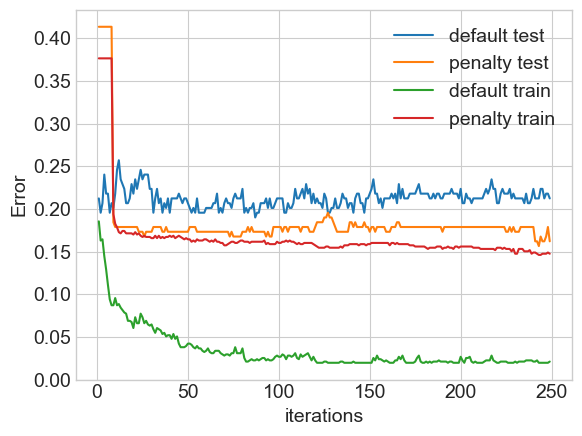

In [800]:
ax = results.plot(x='iterations', y='default test')
results.plot(x='iterations', y='penalty test', ax=ax)
results.plot(x='iterations', y='default train', ax=ax)
results.plot(x='iterations', y='penalty train', ax=ax)
ax.set_ylabel("Error")
plt.show()

In [801]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# 1. Генерация синтетических данных
X, y = make_regression(
    n_samples=200, n_features=5, noise=15, random_state=42
)

# 2. Разделение на train, validation, test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")

# 3. Масштабирование признаков (учим только на train)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 4. Перебор гиперпараметра alpha
alphas = [0.01, 0.1, 1, 10, 100]
results = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    
    y_val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    
    results.append({
        "alpha": alpha,
        "val_mse": val_mse,
        "val_r2": val_r2
    })

results_df = pd.DataFrame(results).sort_values(by="val_mse")
print("\nValidation results:")
print(results_df)

# 5. Выбираем лучший alpha
best_alpha = results_df.iloc[0]["alpha"]
print(f"\nBest alpha: {best_alpha}")

# 6. Обучаем финальную модель на объединенных train+val
X_combined = np.vstack([X_train, X_val])
y_combined = np.hstack([y_train, y_val])

final_model = Ridge(alpha=best_alpha)
final_model.fit(X_combined, y_combined)

# 7. Тестируем на test set
y_test_pred = final_model.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\nTest MSE: {test_mse:.6f}")
print(f"Test R²: {test_r2:.6f}")

# 8. Покажем несколько предсказаний
comparison = pd.DataFrame({
    "y_true": y_test[:10],
    "y_pred": y_test_pred[:10]
})
print("\nSample predictions:")
print(comparison)


Train size: 120, Validation size: 40, Test size: 40

Validation results:
    alpha      val_mse    val_r2
1    0.10   163.651875  0.975360
0    0.01   163.677747  0.975356
2    1.00   163.817562  0.975335
3   10.00   201.827436  0.969612
4  100.00  1634.821810  0.753858

Best alpha: 0.1

Test MSE: 263.166202
Test R²: 0.972434

Sample predictions:
       y_true      y_pred
0  106.038121  126.582763
1  -49.847814  -32.406972
2  -57.910892  -40.353513
3   -4.686019   -5.216474
4  -95.958197 -107.308383
5  110.190207  126.892490
6  -99.402463 -103.630509
7  -54.860287  -28.256566
8  -75.944895  -54.110583
9  144.596472  154.668218


# Brute forcing parameters

In [802]:
# from itertools import product

# predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',"Age_filled", "KNN_prob"]
# outcome = 'Survived'


# X = pd.get_dummies(train_data_recovered[predictors])
# y = train_data_recovered[outcome]


# idx = np.random.choice(range(5), size=len(X), replace=True)
# error = []
# for eta, max_depth in product(np.linspace(0.1,2,20), range(1,15)):
#     xgb = XGBClassifier(objective='binary:logistic', n_estimators=250, 
#                         max_depth=max_depth, learning_rate=eta,
#                         eval_metric='error')
#     cv_error = []
#     for k in range(5):
#         fold_idx = idx == k
#         train_X = X.loc[~fold_idx]; train_y = y[~fold_idx]
#         valid_X = X.loc[fold_idx]; valid_y = y[fold_idx]

#         xgb.fit(train_X, train_y)
#         pred = xgb.predict_proba(valid_X)[:, 1]
#         cv_error.append(np.mean(abs(valid_y - pred) > 0.5))
#     error.append({
#         'eta': eta,
#         'max_depth': max_depth,
#         'avg_error': np.mean(cv_error)
#     })
#     print(error[-1])
# errors = pd.DataFrame(error)
# print(errors)



In [803]:
# errors.sort_values("avg_error").head(10)

In [804]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', "Age_filled", "KNN_prob"]
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors])
y = train_data_recovered[outcome]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model_XGB_penalize = XGBClassifier(objective='binary:logistic', n_estimators=500,
                            max_depth=2, reg_lambda=1000, reg_alpha=0, learning_rate=0.5,
                            subsample=0.1, colsample_bytree=1 , random_state=1)
model_XGB_penalize.fit(X_train, y_train)


print_metrics(y_test, model_XGB_penalize.predict(X_test), 'Test set')
print_metrics(y_train,model_XGB_penalize.predict(X_train), 'Train set')

Metrics for Test set
-----------------------------
Accuracy: 0.8324022346368715
Precision: 0.8333333333333334
Recall: 0.7432432432432432
Logloss: 6.040835763539188
ROC-AUC: 0.8192406692406693


Metrics for Train set
-----------------------------
Accuracy: 0.8286516853932584
Precision: 0.8288288288288288
Recall: 0.6865671641791045
Logloss: 6.176019260494793
ROC-AUC: 0.8004907892967594




In [805]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', "Age_filled", "KNN_prob"]
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors])
y = train_data_recovered[outcome]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model_XGB_penalize = XGBClassifier(objective='binary:logistic', n_estimators=1500, reg_alpha=12,      learning_rate=0.8, subsample=0.4, random_state=3, max_depth=7)
model_XGB_penalize.fit(X_train, y_train)


print_metrics(y_test, model_XGB_penalize.predict(X_test), 'Test set')
print_metrics(y_train,model_XGB_penalize.predict(X_train), 'Train set')


Metrics for Test set
-----------------------------
Accuracy: 0.8379888268156425
Precision: 0.8169014084507042
Recall: 0.7837837837837838
Logloss: 5.839474571421214
ROC-AUC: 0.82998712998713


Metrics for Train set
-----------------------------
Accuracy: 0.8441011235955056
Precision: 0.823045267489712
Recall: 0.746268656716418
Logloss: 5.619165064876411
ROC-AUC: 0.8247109049347855




In [806]:
test_data_dummies = pd.get_dummies(test_data[predictors])
submit_file = pd.DataFrame({"PassengerId": test_data.PassengerId,
                            "Survived": model_XGB_penalize.predict(test_data_dummies)})
submit_file

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [807]:
submit_file.to_csv("data/kaggle_file.csv", index=False)

In [808]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'max_depth': [3, 4, 5, 6],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'n_estimators': [100, 200, 300],
#     'min_child_weight': [1, 3, 5],
#     'gamma': [0, 0.1, 0.2],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0],
#     'reg_alpha': [0, 0.1, 1.0],
#     'reg_lambda': [0, 0.1, 1.0]
# }

# xgb = XGBClassifier(objective='binary:logistic', random_state=42)
# grid_search = GridSearchCV(
#     estimator=xgb,
#     param_grid=param_grid,
#     cv=5,
#     scoring='accuracy',
#     n_jobs=-1,
#     verbose=2
# )

# grid_search.fit(X_train, y_train)
# print("Best parameters:", grid_search.best_params_)

In [809]:
train_data_recovered["Age_over_fare"] = train_data_recovered.Age/train_data_recovered.Fare

In [810]:
# from xgboost import XGBClassifier, callback

# model_XGB = XGBClassifier(
#     objective='binary:logistic',
#     n_estimators=1000,
#     learning_rate=0.01,
#     max_depth=4,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     eval_metric='logloss'
# )

# # Early stopping callback (3.x-compatible)
# early_stop = callback.EarlyStopping(
#     rounds=50,
#     save_best=True,
#     data_name='validation_1',  # name of the validation set in eval_set
#     maximize=False
# )

# # Now fit — NOTE: no early_stopping_rounds or verbose args
# model_XGB.fit(
#     X_train,
#     y_train,
#     eval_set=[(X_train, y_train), (X_test, y_test)],
#     callbacks=[early_stop]
# )


# print_metrics(y_test, model_XGB.predict(X_test), 'Test set')
# print_metrics(y_train,model_XGB.predict(X_train), 'Train set')


In [811]:
import xgboost

print(xgboost.__version__)

3.0.5


In [812]:
import xgboost as xgb
import numpy as np

# Prepare DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_test,  label=y_test)

params = {
    "objective": "binary:logistic",
    "learning_rate": 0.1,
    "max_depth": 4,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "logloss"
}

# callback for early stopping (3.x compatible)
early_stop_cb = xgb.callback.EarlyStopping(rounds=100, save_best=True)

bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=[(dtrain, "train"), (dval, "validation")],
    callbacks=[early_stop_cb],
    verbose_eval=100
)

# pick prediction using best iteration if available
best_iter = getattr(bst, "best_iteration", None)
best_ntree = getattr(bst, "best_ntree_limit", None)

if best_iter is not None:
    preds_proba = bst.predict(dval, iteration_range=(0, best_iter + 1))
elif best_ntree is not None:
    # fallback for some versions
    preds_proba = bst.predict(dval, ntree_limit=best_ntree)
else:
    preds_proba = bst.predict(dval)

# threshold to class labels
preds = (preds_proba >= 0.5).astype(int)

print_metrics(y_test, preds, "Test set")
print_metrics(y_train, (bst.predict(dtrain) >= 0.5).astype(int), "Train set")


[0]	train-logloss:0.61554	validation-logloss:0.63403
[100]	train-logloss:0.24682	validation-logloss:0.41058
[154]	train-logloss:0.21360	validation-logloss:0.41967
Metrics for Test set
-----------------------------
Accuracy: 0.8212290502793296
Precision: 0.8387096774193549
Recall: 0.7027027027027027
Logloss: 6.443558147775134
ROC-AUC: 0.8037323037323038


Metrics for Train set
-----------------------------
Accuracy: 0.8946629213483146
Precision: 0.9141630901287554
Recall: 0.7947761194029851
Logloss: 3.79673315194352
ROC-AUC: 0.87486553717897




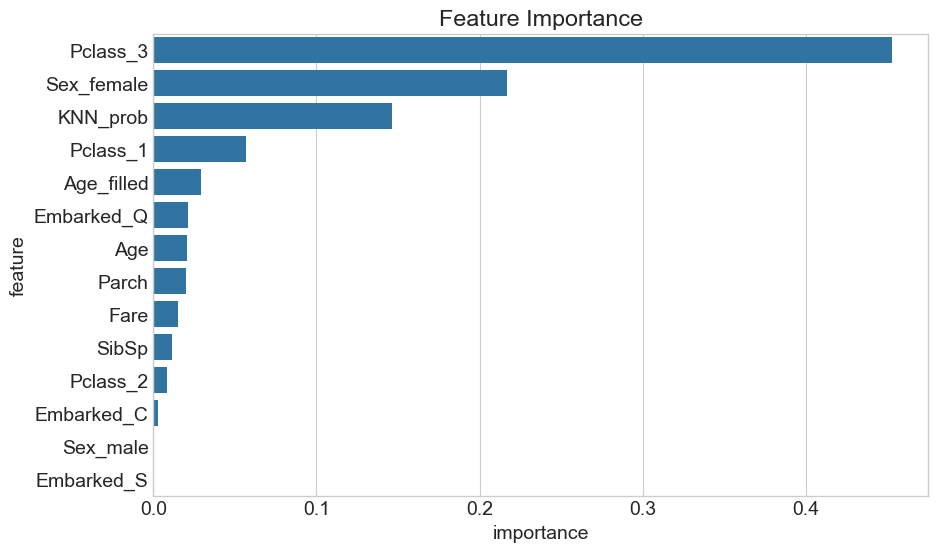

Top 10 most important features:
       feature  importance
8     Pclass_3    0.452644
9   Sex_female    0.216567
5     KNN_prob    0.146042
6     Pclass_1    0.056587
4   Age_filled    0.029062
12  Embarked_Q    0.021352
0          Age    0.020457
2        Parch    0.019815
3         Fare    0.015109
1        SibSp    0.011224
7     Pclass_2    0.008403
11  Embarked_C    0.002737
10    Sex_male    0.000000
13  Embarked_S    0.000000


In [813]:
def plot_feature_importance(model, X):
    importance = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=importance)
    plt.title('Feature Importance')
    plt.show()
    return importance

# After training your model:
importance_df = plot_feature_importance(model_XGB_penalize, X)
print("Top 10 most important features:")
print(importance_df.head(15))

In [814]:
%matplotlib inline

In [815]:
train_data_recovered

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone,Age_filled,Ticket_int,Cabin_str,KNN_prob,Age_over_fare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0,0,21171,NaN,0.133333,3.034483
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0,0,17599,C,1.000000,0.533084
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1,0,3101282,NaN,0.466667,3.280757
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0,0,113803,C,1.000000,0.659134
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1,0,373450,NaN,0.066667,4.347826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1,0,211536,NaN,0.066667,2.076923
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1,0,112053,B,1.000000,0.633333
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,NaN,0,1,6607,NaN,0.400000,1.194030
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1,0,111369,C,0.466667,0.866667


In [816]:
from sklearn.ensemble import VotingClassifier

# Create the voting classifier
voting_clf = VotingClassifier(estimators=[
    ('xgb', model_XGB_penalize),
    ('rf', model_rf),
    ('lr', model_main)
], voting='soft')

# Train
voting_clf.fit(X_train, y_train)

# Predict
y_pred = voting_clf.predict(X_test)
print_metrics(y_test, y_pred, "Ensemble Model")

Metrics for Ensemble Model
-----------------------------
Accuracy: 0.8324022346368715
Precision: 0.84375
Recall: 0.7297297297297297
Logloss: 6.040835763539188
ROC-AUC: 0.8172458172458174




# Regularization

In [859]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', "Age_filled", "KNN_prob"]
outcome = 'Survived'

X = pd.get_dummies(train_data_recovered[predictors], drop_first=True)
y = train_data_recovered[outcome]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, shuffle=True, test_size=0.2)

alphas = list(np.logspace(-6,6,26))
l1_ratios = list(np.linspace(0,1,5))

models_r = []
models_l = []

coefs_r = []
coefs_l = []


for alpha in alphas:
    model = LogisticRegression(penalty="l2",C=1/alpha, solver="liblinear", random_state=42).fit(X_train, y_train)
    models_r.append(model)
    coefs_r.append(model.coef_[0])

    model = LogisticRegression(penalty="l1",C=1/alpha, solver="liblinear", random_state=42).fit(X_train, y_train)
    models_l.append(model)
    coefs_l.append(model.coef_[0])


In [860]:
df_lasso = pd.DataFrame(coefs_l, index=alphas, columns=X_train.columns)
df_lasso

,Age,SibSp,Parch,Fare,Age_filled,KNN_prob,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0.000001,-0.006855,0.050762,-0.170643,0.000373,-0.408052,7.186251,0.476531,0.522224,0.471730,-0.995275,-0.107884
0.000003,-0.006855,0.050762,-0.170643,0.000373,-0.408052,7.186247,0.476530,0.522222,0.471728,-0.995273,-0.107884
0.000009,-0.006855,0.050762,-0.170643,0.000373,-0.408052,7.186234,0.476526,0.522216,0.471723,-0.995269,-0.107884
0.000028,-0.006856,0.050759,-0.170642,0.000373,-0.408052,7.186196,0.476514,0.522198,0.471706,-0.995258,-0.107884
0.000083,-0.006856,0.050753,-0.170639,0.000373,-0.408052,7.186078,0.476477,0.522144,0.471655,-0.995223,-0.107884
0.000251,-0.006858,0.050732,-0.170629,0.000373,-0.408052,7.185724,0.476365,0.521982,0.471502,-0.995117,-0.107884
0.000759,-0.006864,0.050671,-0.170601,0.000372,-0.408052,7.184655,0.476029,0.521493,0.471040,-0.994796,-0.107883
0.002291,-0.006883,0.050486,-0.170515,0.000371,-0.408051,7.181426,0.475013,0.520014,0.469646,-0.993829,-0.107882
0.006918,-0.006939,0.049928,-0.170255,0.000368,-0.408049,7.171683,0.471948,0.515550,0.465435,-0.990910,-0.107876
0.020893,-0.007108,0.048244,-0.169474,0.000360,-0.408044,7.142317,0.462703,0.502085,0.452731,-0.982114,-0.107859


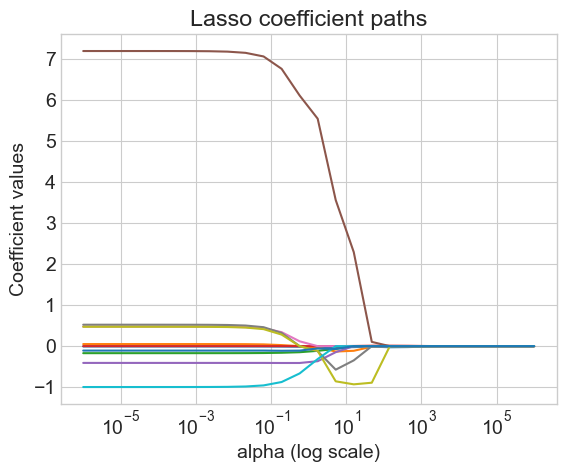

In [861]:

ax = df_lasso.plot(logx=True, legend=False)
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("Coefficient values")
ax.set_title("Lasso coefficient paths")
plt.show()

In [862]:
results_l = pd.DataFrame({"alpha":[],
                        "test":[],
                        "train":[]})


for i,alpha in enumerate(alphas):
    results_l.loc[len(results_l)] = {"alpha": alpha,
                                    "test": accuracy_score(y_test, models_l[i].predict(X_test)),
                                    "train": accuracy_score(y_train, models_l[i].predict(X_train))}

results_l.sort_values(by=["test","train"], ascending=False).head()

,alpha,test,train
12,0.575440,0.854749,0.828652
9,0.020893,0.843575,0.831461
13,1.737801,0.843575,0.831461
7,0.002291,0.843575,0.830056
8,0.006918,0.843575,0.830056


In [863]:
df_ridge = pd.DataFrame(coefs_r, index=alphas, columns=X_train.columns)
df_ridge

,Age,SibSp,Parch,Fare,Age_filled,KNN_prob,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0.000001,-0.006821,0.051048,-0.170850,0.000377,-0.408706,7.191485,4.778608e-01,0.524357,0.474189,-0.992853,-0.106333
0.000003,-0.006810,0.051006,-0.170577,0.000377,-0.407914,7.191304,4.783346e-01,0.524829,0.474305,-0.994475,-0.106969
0.000009,-0.006826,0.050962,-0.170845,0.000378,-0.408348,7.191254,4.795686e-01,0.525027,0.473724,-0.994562,-0.107684
0.000028,-0.006812,0.051044,-0.170636,0.000376,-0.407745,7.191645,4.782339e-01,0.524829,0.474243,-0.995931,-0.107303
0.000083,-0.006814,0.050951,-0.170514,0.000377,-0.407009,7.190368,4.782059e-01,0.524304,0.473875,-0.995152,-0.106730
0.000251,-0.006833,0.050900,-0.170797,0.000377,-0.408380,7.189588,4.788783e-01,0.524328,0.473100,-0.994618,-0.107811
0.000759,-0.006840,0.050772,-0.170583,0.000376,-0.407902,7.185746,4.769815e-01,0.522719,0.471855,-0.994881,-0.107681
0.002291,-0.006901,0.050201,-0.170502,0.000376,-0.408145,7.173658,4.744163e-01,0.518388,0.466879,-0.993001,-0.108581
0.006918,-0.007078,0.048468,-0.170041,0.000378,-0.408972,7.136221,4.660036e-01,0.504654,0.451905,-0.983752,-0.109748
0.020893,-0.007596,0.043587,-0.169213,0.000382,-0.411535,7.030439,4.442232e-01,0.467428,0.408893,-0.967158,-0.117675


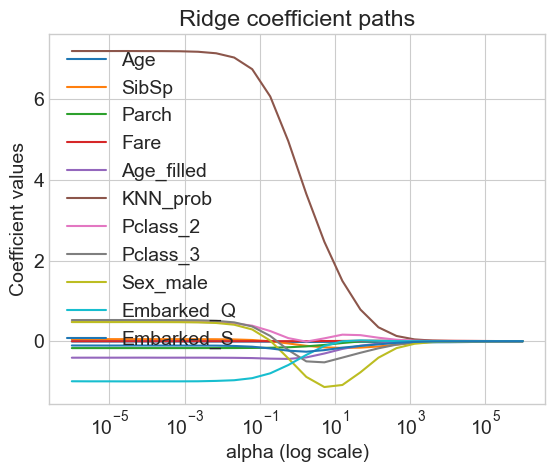

In [864]:

ax = df_ridge.plot(logx=True, legend=True)
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("Coefficient values")
ax.set_title("Ridge coefficient paths")
plt.show()

In [865]:
results_r = pd.DataFrame({"alpha":[],
                        "test":[],
                        "train":[]})


for i,alpha in enumerate(alphas):
    results_r.loc[len(results_r)] = {"alpha": alpha,
                                    "test": accuracy_score(y_test, models_r[i].predict(X_test)),
                                    "train": accuracy_score(y_train, models_r[i].predict(X_train))}

results_r.sort_values(by=["test","train"], ascending=False).head()

,alpha,test,train
11,0.190546,0.843575,0.831461
8,0.006918,0.843575,0.830056
10,0.063096,0.843575,0.827247
12,0.575440,0.843575,0.827247
9,0.020893,0.843575,0.825843


In [866]:
models_el = []
coefs_el = []

for l1 in l1_ratios:
    for alpha in alphas:
        model = LogisticRegression(penalty="elasticnet", C=1/alpha, solver="saga", l1_ratio=l1, random_state=42).fit(X_train, y_train)
        models_el.append(model)
        coefs_el.append(model.coef_[0])

coefs_el = pd.DataFrame(coefs_el)
coefs_el["alpha"] = alphas*5
coefs_el["l1_score"] = [0]*130

cnt = 0
for i,row in coefs_el.iterrows():
    if i == 0:
        continue
    if i % 26 == 0:
        cnt += 1
    a = l1_ratios[cnt]
    coefs_el.loc[i, "l1_score"] = a

coefs_el.columns = list(X_train.columns) + ["alpha"] + ["f1_score"]
coefs_el

/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was

,Age,SibSp,Parch,Fare,Age_filled,KNN_prob,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,alpha,f1_score
0,-0.026043,-0.043576,-0.006728,0.013009,-0.011463,0.046292,0.013393,-0.036523,-0.065436,0.000511,-0.018429,0.000001,0.0
1,-0.026043,-0.043576,-0.006728,0.013009,-0.011463,0.046292,0.013393,-0.036523,-0.065436,0.000511,-0.018429,0.000003,0.0
2,-0.026043,-0.043576,-0.006728,0.013009,-0.011463,0.046292,0.013393,-0.036523,-0.065436,0.000511,-0.018429,0.000009,0.0
3,-0.026043,-0.043576,-0.006728,0.013009,-0.011463,0.046292,0.013393,-0.036523,-0.065436,0.000511,-0.018429,0.000028,0.0
4,-0.026043,-0.043576,-0.006728,0.013009,-0.011463,0.046292,0.013393,-0.036523,-0.065436,0.000511,-0.018429,0.000083,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12022.644346,1.0
126,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,36307.805477,1.0
127,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,109647.819614,1.0
128,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,331131.121483,1.0


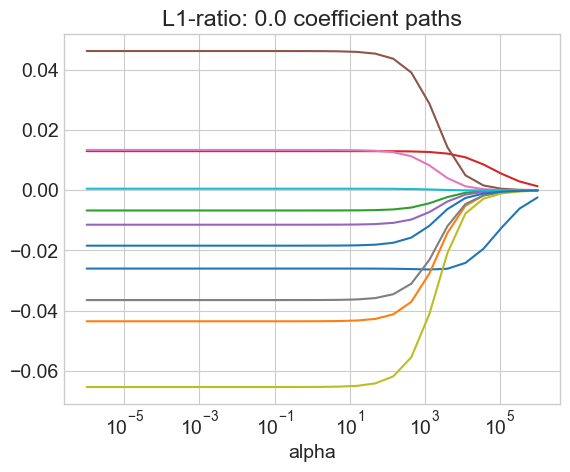

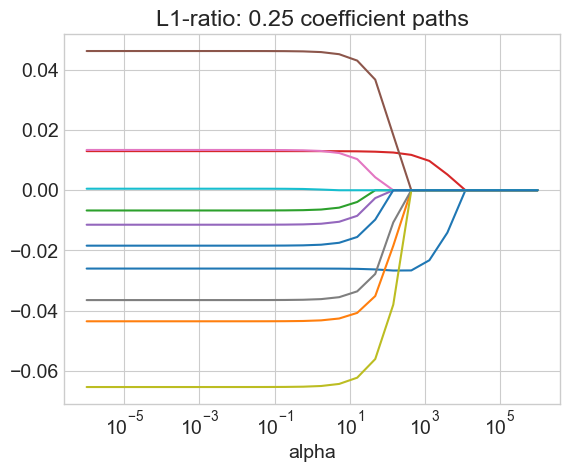

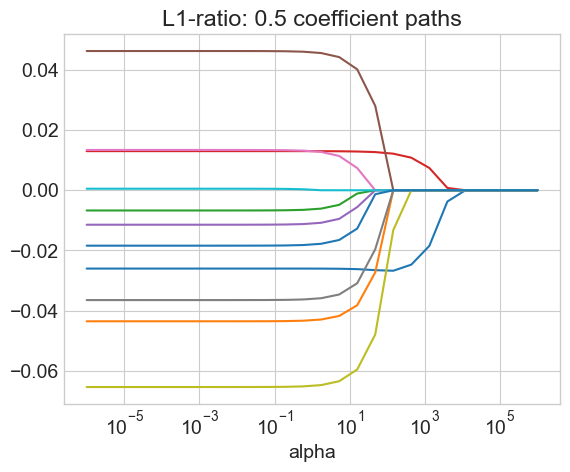

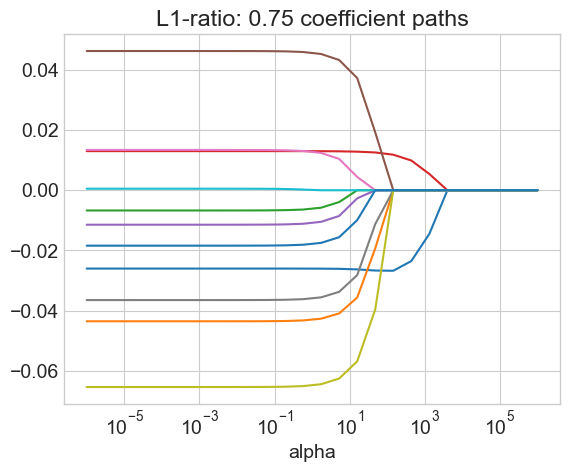

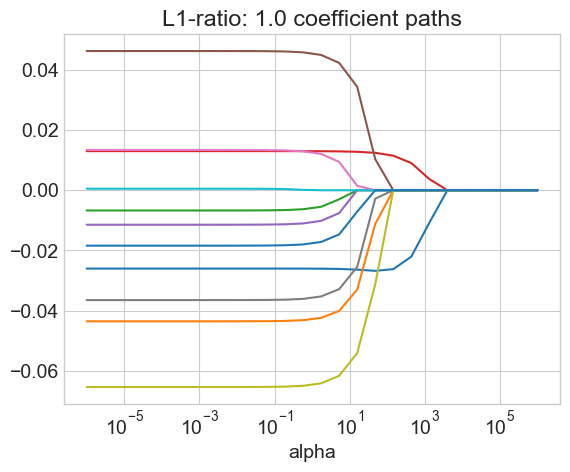

In [867]:
for i in range(5):
    # plt.figure(figsize=(10,7))
    df_elastic = pd.DataFrame(coefs_el.loc[i*26:i*26+25, list(X_train.columns) + ["alpha"]]).set_index("alpha")
    ax = df_elastic.plot(legend=False, logx=True)
    ax.set_title(f"L1-ratio: {l1_ratios[i]} coefficient paths")
    plt.show()
    # print(df_elastic)
    

In [873]:
results = pd.DataFrame({"alpha":[],
                        "l1":[],
                        "test":[],
                        "train":[]})

i = 0
for l1 in l1_ratios:
    for alpha in alphas:
        results.loc[len(results)] = {"alpha": alpha,
                                     "l1": l1,
                                     "test": accuracy_score(y_test, models_el[i].predict(X_test)),
                                     "train": accuracy_score(y_train, models_el[i].predict(X_train))}
        i+=1

results.sort_values(by=["test"], ascending=False)

,alpha,l1,test,train
0,0.000001,0.00,0.681564,0.699438
52,0.000001,0.50,0.681564,0.699438
84,0.000759,0.75,0.681564,0.699438
83,0.000251,0.75,0.681564,0.699438
82,0.000083,0.75,0.681564,0.699438
...,...,...,...,...
102,331131.121483,0.75,0.586592,0.623596
101,109647.819614,0.75,0.586592,0.623596
100,36307.805477,0.75,0.586592,0.623596
99,12022.644346,0.75,0.586592,0.623596


In [874]:
print(alphas[12])
models_l[12]

0.5754399373371566


,penalty,'l1'
,dual,False
,tol,0.0001
,C,np.float64(1.7378008287493765)
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [875]:
model_log_new = LogisticRegression(penalty="l1",solver="liblinear", C=1/alphas[12], max_iter=1000, random_state=42)
model_log_new.fit(X_train, y_train)

print_metrics(y_test, model_log_new.predict(X_test), "new logistic model")

Metrics for new logistic model
-----------------------------
Accuracy: 0.8547486033519553
Precision: 0.8333333333333334
Recall: 0.8108108108108109
Logloss: 5.235390995067296
ROC-AUC: 0.8482625482625483




In [876]:
test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)

submit_file = pd.DataFrame({"Survived":model_log_new.predict(test_data_dummies),
              "PassengerId": test_data.PassengerId})

submit_file.to_csv("data/submit_file.csv",index=False)

# Scalers

In [878]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler_minmax = MinMaxScaler()
scaler_minmax.fit(X_train)

X_train_minmax = scaler_minmax.transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)


model_log_new_scaled = LogisticRegression(penalty="l1",solver="liblinear", C=1/alphas[12], max_iter=1000, random_state=42)
model_log_new_scaled.fit(X_train_minmax, y_train)

print_metrics(y_test, model_log_new_scaled.predict(X_test_minmax), "new logistic model")

Metrics for new logistic model
-----------------------------
Accuracy: 0.8435754189944135
Precision: 0.8285714285714286
Recall: 0.7837837837837838
Logloss: 5.638113379303242
ROC-AUC: 0.8347490347490346




In [879]:
scaler_standard = StandardScaler()
scaler_standard.fit(X_train)

X_train_standard = scaler_standard.transform(X_train)
X_test_standard = scaler_standard.transform(X_test)


model_log_new_scaled = LogisticRegression(penalty="l1",solver="liblinear", C=1/alphas[12], max_iter=1000, random_state=42)
model_log_new_scaled.fit(X_train_standard, y_train)

print_metrics(y_test, model_log_new_scaled.predict(X_test_standard), "new logistic model")


Metrics for new logistic model
-----------------------------
Accuracy: 0.8435754189944135
Precision: 0.8285714285714286
Recall: 0.7837837837837838
Logloss: 5.638113379303242
ROC-AUC: 0.8347490347490346




In [880]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str,Ticket_int,Cabin_str,KNN_prob
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0,0,A/5,21171,NaN,0.133333
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0,0,PC,17599,C,1.000000
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1,0,STON/O2.,3101282,NaN,0.466667
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0,0,NaN,113803,C,1.000000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1,0,NaN,373450,NaN,0.066667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1,0,NaN,211536,NaN,0.066667
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1,0,NaN,112053,B,1.000000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0,1,W./C.,6607,NaN,0.400000
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1,0,NaN,111369,C,0.466667


In [886]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', "Age_filled"]
outcome = 'Survived'

X = pd.get_dummies(train_data_recovered[predictors])
y = train_data_recovered[outcome]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, shuffle=True, test_size=0.2)

scaler_standard = StandardScaler()
scaler_standard.fit(X_train)

X_train_standard = scaler_standard.transform(X_train)
X_test_standard = scaler_standard.transform(X_test)

model_knn_scaled = KNeighborsClassifier(n_neighbors=15)
model_knn_scaled.fit(X_train_standard, y_train)

print_metrics(y_test, model_knn_scaled.predict(X_test_standard), "Test KNN Standard model")
print_metrics(y_train, model_knn_scaled.predict(X_train_standard), "Train KNN Standard model")



Metrics for Test KNN Standard model
-----------------------------
Accuracy: 0.7932960893854749
Precision: 0.8135593220338984
Recall: 0.6486486486486487
Logloss: 7.450364108364997
ROC-AUC: 0.7719433719433719


Metrics for Train KNN Standard model
-----------------------------
Accuracy: 0.8286516853932584
Precision: 0.8724489795918368
Recall: 0.6380597014925373
Logloss: 6.176019260494794
ROC-AUC: 0.7908766975931155




In [907]:

scaler_minmax = MinMaxScaler()
scaler_minmax.fit(X_train)

X_train_minmax = scaler_minmax.transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)

model_knn_scaled = KNeighborsClassifier(n_neighbors=13)
model_knn_scaled.fit(X_train_minmax, y_train)

print_metrics(y_test, model_knn_scaled.predict(X_test_minmax), "Test KNN MinMax model")
print_metrics(y_train, model_knn_scaled.predict(X_train_minmax), "Train KNN MinMax model")

Metrics for Test KNN MinMax model
-----------------------------
Accuracy: 0.8044692737430168
Precision: 0.819672131147541
Recall: 0.6756756756756757
Logloss: 7.047641724129053
ROC-AUC: 0.7854568854568855


Metrics for Train KNN MinMax model
-----------------------------
Accuracy: 0.8258426966292135
Precision: 0.8636363636363636
Recall: 0.6380597014925373
Logloss: 6.277265477879953
ROC-AUC: 0.7886244453408632




In [916]:
scaler_standard = StandardScaler()
scaler_standard.fit(X)

X_scaled = scaler_standard.transform(X)

model_knn_scaled = KNeighborsClassifier(n_neighbors=13)
model_knn_scaled.fit(X_scaled, train_data.Survived)

train_data_recovered["KNN_prob_scaled"] = model_knn_scaled.predict_proba(X)[:,1]


/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [917]:
train_data_recovered.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone,Age_filled,Ticket_int,Cabin_str,KNN_prob,Age_over_fare,KNN_prob_scaled
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0,0,21171,NaN,0.133333,3.034483,0.307692
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0,0,17599,C,1.000000,0.533084,0.846154
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1,0,3101282,NaN,0.466667,3.280757,0.307692
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0,0,113803,C,1.000000,0.659134,0.846154
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1,0,373450,NaN,0.066667,4.347826,0.153846
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,NaN,1,1,330877,NaN,0.066667,3.310358,0.307692
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,54.0,1,0,17463,E,0.200000,1.041215,0.846154
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,2.0,0,0,349909,NaN,0.266667,0.094899,0.692308
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,27.0,0,0,347742,NaN,0.466667,2.425157,0.461538
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,14.0,0,0,237736,NaN,0.600000,0.465568,0.846154


<Axes: >

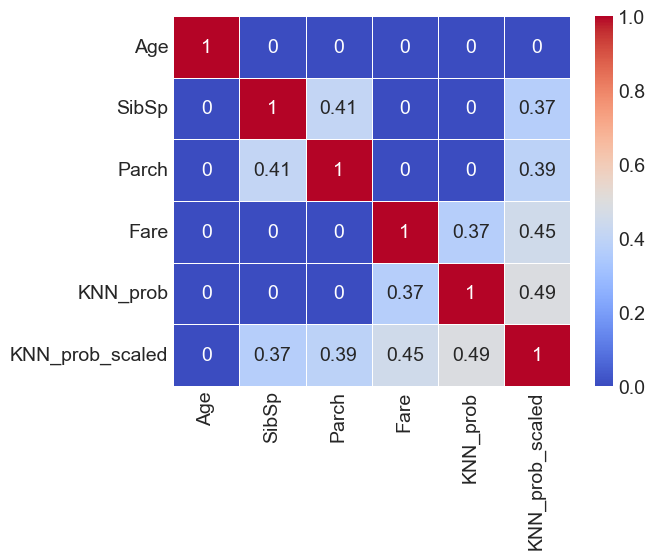

In [920]:


predictors = [ 'Age', 'SibSp', 'Parch', 'Fare',"KNN_prob", "KNN_prob_scaled"]

corr_matrix = train_data_recovered[predictors].corr()
corr_matrix = np.round(corr_matrix, 2)
corr_matrix[np.abs(corr_matrix) < 0.3] = 0


sns.heatmap(corr_matrix, annot=True, linewidths=.5, cmap="coolwarm")

In [ ]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', "Age_filled", "KNN_prob_scaled", "KNN_prob"]
outcome = 'Survived'

X = pd.get_dummies(train_data_recovered[predictors],drop_first=True)
y = train_data_recovered[outcome]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, shuffle=True, test_size=0.2)

model_log_new = LogisticRegression(penalty="l1",solver="liblinear", C=1/alphas[12], max_iter=1000, random_state=42)
model_log_new.fit(X_train, y_train)

print_metrics(y_test, model_log_new.predict(X_test), "new logistic model")

Metrics for new logistic model
-----------------------------
Accuracy: 0.8547486033519553
Precision: 0.8333333333333334
Recall: 0.8108108108108109
Logloss: 5.235390995067296
ROC-AUC: 0.8482625482625483




In [940]:
pd.DataFrame(X_train_standard).describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12
count,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,712.000000
mean,1.746418e-17,1.746418e-17,2.245395e-17,5.363999e-17,-2.120651e-17,-8.732091e-18,8.482603e-17,4.490790e-17,9.979533e-18,-9.979533e-18,-4.490790e-17,1.871162e-18,0.000000
std,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703
min,-2.214363e+00,-4.707224e-01,-4.793416e-01,-6.274674e-01,-4.947274e-01,-5.448885e-01,-5.188085e-01,-1.125840e+00,-7.243102e-01,-1.380624e+00,-4.614620e-01,-3.033555e-01,-1.687794
25%,-5.542135e-01,-4.707224e-01,-4.793416e-01,-4.748670e-01,-4.947274e-01,-5.448885e-01,-5.188085e-01,-1.125840e+00,-7.243102e-01,-1.380624e+00,-4.614620e-01,-3.033555e-01,-1.687794
50%,-9.263364e-02,-4.707224e-01,-4.793416e-01,-3.491435e-01,-4.947274e-01,-5.448885e-01,-5.188085e-01,8.882256e-01,-7.243102e-01,7.243102e-01,-4.614620e-01,-3.033555e-01,0.592489
75%,4.458762e-01,3.799232e-01,-4.793416e-01,-4.017244e-02,-4.947274e-01,-5.448885e-01,-5.188085e-01,8.882256e-01,1.380624e+00,7.243102e-01,-4.614620e-01,-3.033555e-01,0.592489
max,3.907725e+00,6.334442e+00,7.104908e+00,9.237724e+00,2.021315e+00,1.835238e+00,1.927494e+00,8.882256e-01,1.380624e+00,7.243102e-01,2.167026e+00,3.296463e+00,0.592489


In [941]:
pd.DataFrame(X_train_minmax).describe()


,0,1,2,3,4,5,6,7,8,9,10,11,12
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,0.361701,0.069171,0.063202,0.063604,0.196629,0.228933,0.212079,0.558989,0.344101,0.655899,0.175562,0.084270,0.740169
std,0.163458,0.147051,0.131945,0.101438,0.397729,0.420441,0.409068,0.496857,0.475408,0.475408,0.380714,0.277987,0.438850
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.271174,0.000000,0.000000,0.015469,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.346569,0.000000,0.000000,0.028213,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,0.434531,0.125000,0.000000,0.059532,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
